# Churn Definition and Interpurchase-Gap Analysis

## Objective

Determine a defensible inactivity period for defining customer churn. **How long can a customer remain inactive before we reasonably classify them as churned?**

This analysis examines:

- time between consecutive purchases;
- one-time versus repeat customers;
- variation in purchase gaps across customers;
- the share of repeat purchases captured by candidate horizons;
- sensitivity of the churn definition to 30-, 60-, 90-, 120- and 180-day thresholds;
- right-censoring near the end of the dataset.

The selected threshold will define churn as:

> A customer is churned at a snapshot date when they make no retained purchase
> during the following prediction horizon.

This notebook defines the target. It does not train a model.

Import Data

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from customer_intelligence.churn import (
    build_snapshot_labels,
    generate_monthly_snapshot_dates,
)

from matplotlib.ticker import PercentFormatter

# Make imports work when the notebook is opened from /notebooks
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence import (
    load_transactions,
    tag_invoice_type,
    build_model_df,
)

from customer_intelligence.segmentation import build_purchases_df
from customer_intelligence.segmentation.viz import apply_style, style_ax

apply_style()
sns.set_context("notebook")

BLUE = "#2A78D6"
ORANGE = "#EB6834"
GREEN = "#54A24B"
RED = "#E45756"
GRAY = "#898781"

DATA_PATH = PROJECT_ROOT / "uci data" / "online_retail_II.xlsx"

Build the cancellation-aware purchase history - gaps should be calculated from purchases that remained after cancellation reconciliation. A completely reversed invoice should not reset a customer’s activity clock.

In [3]:
raw_df = load_transactions(DATA_PATH)
tagged_df = tag_invoice_type(raw_df)
model_df = build_model_df(tagged_df)

# FIFO cancellation reconciliation
purchases_df = build_purchases_df(model_df)

print(f"Raw transaction rows: {len(raw_df):,}")
print(f"Customer-attributed merchandise rows: {len(model_df):,}")
print(f"Retained purchase rows: {len(purchases_df):,}")
print(f"Customers with retained purchases: {purchases_df['Customer ID'].nunique():,}")
print(
    "Observed period:",
    purchases_df["InvoiceDate"].min(),
    "to",
    purchases_df["InvoiceDate"].max(),
)

Raw transaction rows: 1,067,371
Customer-attributed merchandise rows: 820,647
Retained purchase rows: 795,583
Customers with retained purchases: 5,840
Observed period: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


Build an invoice-level purchase table - Interpurchase gaps are calculated between orders, not individual product lines.

In [4]:
order_df = (
    purchases_df
    .groupby(["Customer ID", "Invoice"], as_index=False)
    .agg(
        PurchaseDate=("InvoiceDate", "min"),
        OrderValue=("NetRevenue", "sum"),
        Units=("remaining_quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
    )
    .sort_values(["Customer ID", "PurchaseDate", "Invoice"])
    .reset_index(drop=True)
)

assert order_df[["Customer ID", "Invoice"]].duplicated().sum() == 0
assert order_df["PurchaseDate"].notna().all()
assert (order_df["OrderValue"] >= 0).all()

print(f"Retained invoices: {len(order_df):,}")
print(f"Customers: {order_df['Customer ID'].nunique():,}")

display(order_df.head())

Retained invoices: 36,425
Customers: 5,840


,Customer ID,Invoice,PurchaseDate,OrderValue,Units,UniqueProducts
0,12346,499763,2010-03-02 13:08:00,27.05,5,5
1,12346,513774,2010-06-28 13:53:00,142.31,19,19
2,12347,529924,2010-10-31 14:20:00,611.53,509,40
3,12347,537626,2010-12-07 14:57:00,1423.58,638,31
4,12347,542237,2011-01-26 14:30:00,475.39,315,29


Calculate interpurchase gaps - Calculate the elapsed time between consecutive invoices for each customer. A gap of zero days is valid: the customer placed more than one invoice on the same calendar day.

In [5]:
order_df["PreviousPurchaseDate"] = (
    order_df
    .groupby("Customer ID")["PurchaseDate"]
    .shift(1)
)

order_df["GapHours"] = (
    order_df["PurchaseDate"] - order_df["PreviousPurchaseDate"]
).dt.total_seconds() / 3600

order_df["GapDaysExact"] = order_df["GapHours"] / 24

# Calendar-day version is easier to communicate to stakeholders
order_df["PurchaseDay"] = order_df["PurchaseDate"].dt.normalize()

order_df["PreviousPurchaseDay"] = (
    order_df
    .groupby("Customer ID")["PurchaseDay"]
    .shift(1)
)

order_df["GapDays"] = (
    order_df["PurchaseDay"] - order_df["PreviousPurchaseDay"]
).dt.days

gap_df = order_df[order_df["PreviousPurchaseDate"].notna()].copy()

assert (gap_df["GapHours"] >= 0).all()
assert (gap_df["GapDays"] >= 0).all()

print(f"Observed repeat-purchase gaps: {len(gap_df):,}")
display(gap_df.head())

Observed repeat-purchase gaps: 30,585


,Customer ID,Invoice,PurchaseDate,OrderValue,Units,UniqueProducts,PreviousPurchaseDate,GapHours,GapDaysExact,PurchaseDay,PreviousPurchaseDay,GapDays
1,12346,513774,2010-06-28 13:53:00,142.31,19,19,2010-03-02 13:08:00,2832.750000,118.031250,2010-06-28,2010-03-02,118.0
3,12347,537626,2010-12-07 14:57:00,1423.58,638,31,2010-10-31 14:20:00,888.616667,37.025694,2010-12-07,2010-10-31,37.0
4,12347,542237,2011-01-26 14:30:00,475.39,315,29,2010-12-07 14:57:00,1199.550000,49.981250,2011-01-26,2010-12-07,50.0
5,12347,549222,2011-04-07 10:43:00,636.25,483,24,2011-01-26 14:30:00,1700.216667,70.842361,2011-04-07,2011-01-26,71.0
6,12347,556201,2011-06-09 13:01:00,382.52,196,18,2011-04-07 10:43:00,1514.300000,63.095833,2011-06-09,2011-04-07,63.0


Meaning:
Each row represents one completed period between two observed customer orders.

The first order for each customer has no gap because there is no earlier observed purchase.
Your assertions correctly confirm that:
- gaps cannot be negative;
- purchase dates are in chronological order;
- every retained invoice appears only once.

Profile one-time and repeat customers - This is essential because customers with one order have no observed interpurchase gap.

In [6]:
customer_order_counts = (
    order_df
    .groupby("Customer ID")
    .agg(
        Orders=("Invoice", "nunique"),
        FirstPurchase=("PurchaseDate", "min"),
        LastPurchase=("PurchaseDate", "max"),
        TotalValue=("OrderValue", "sum"),
    )
    .reset_index()
)

customer_order_counts["CustomerType"] = np.where(
    customer_order_counts["Orders"] == 1,
    "One-time customer",
    "Repeat customer",
)

customer_type_summary = (
    customer_order_counts["CustomerType"]
    .value_counts()
    .rename_axis("CustomerType")
    .reset_index(name="Customers")
)

customer_type_summary["Share"] = (
    customer_type_summary["Customers"]
    / customer_type_summary["Customers"].sum()
)

display(customer_type_summary)

,CustomerType,Customers,Share
0,Repeat customer,4224,0.723288
1,One-time customer,1616,0.276712


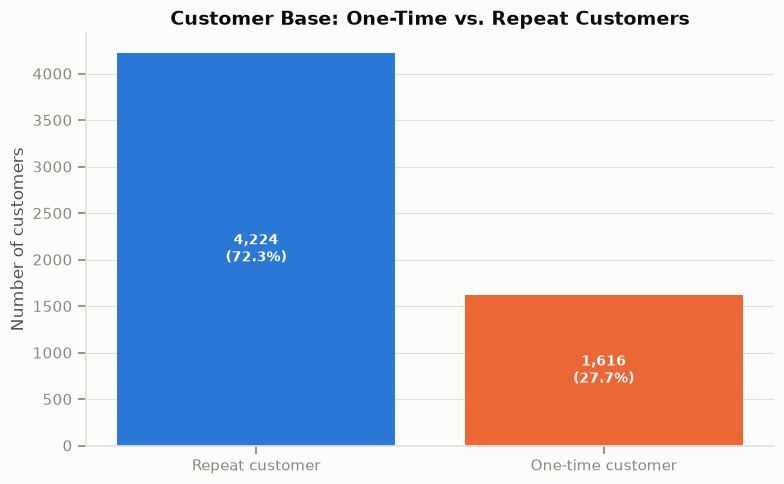

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    customer_type_summary["CustomerType"],
    customer_type_summary["Customers"],
    color=[BLUE, ORANGE],
)

ax.set_title(
    "Customer Base: One-Time vs. Repeat Customers",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Number of customers")

for bar, customers, share in zip(
    bars,
    customer_type_summary["Customers"],
    customer_type_summary["Share"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,  # Positioned inside at half the bar height
        f"{customers:,}\n({share:.1%})",
        ha="center",
        va="center",  # Center vertically inside the bar
        fontsize=10,
        color="white",  # White text for high contrast against BLUE/ORANGE
        weight="bold",
    )

style_ax(ax)
plt.tight_layout()
plt.show()

Meaning:
- Repeat customers have at least two retained invoices.
- One-time customers have only one retained invoice.
This distinction is important:
- losing a repeat customer is conventional churn;
- a one-time buyer not returning is a second-purchase conversion problem.
They can both appear in a future model, but they should not necessarily receive the same campaign.

Inspect zero-day and very short gaps - If same-day invoices represent split orders rather than genuinely separate visits, perform a sensitivity comparison using purchase days instead of invoice numbers. This suggests that some customers placed multiple invoices during the same shopping period.
Treating every same-day invoice as a separate customer visit could make purchasing frequency appear artificially high and make gaps look shorter.

In [8]:
short_gap_summary = pd.Series({
    "Same calendar day": (gap_df["GapDays"] == 0).sum(),
    "Within 1 day (Within 24 hours)": (gap_df["GapDaysExact"] <= 1).sum(),
    "Within 7 days": (gap_df["GapDaysExact"] <= 7).sum(),
    "All observed gaps": len(gap_df),
})

display(short_gap_summary.to_frame("Count"))

print(
    f"Same-day gaps: "
    f"{(gap_df['GapDays'] == 0).mean():.1%} of observed gaps"
)

,Count
Same calendar day,3646
Within 1 day (Within 24 hours),4002
Within 7 days,7481
All observed gaps,30585


Same-day gaps: 11.9% of observed gaps


Create a daily purchase version for sensitivity analysis - Use daily_gap_df as the main stakeholder view because multiple invoices on the same day usually represent one period of customer activity.
daily_purchase_df: one purchase occasion per day. You combine all invoices placed by the same customer on the same calendar day.
Meaning:
One row represents a customer being active on one distinct purchase day.

In [9]:
daily_purchase_df = (
    order_df
    .groupby(["Customer ID", "PurchaseDay"], as_index=False)
    .agg(
        DailyValue=("OrderValue", "sum"),
        Invoices=("Invoice", "nunique"),
    )
    .sort_values(["Customer ID", "PurchaseDay"])
)

daily_purchase_df["PreviousPurchaseDay"] = (
    daily_purchase_df
    .groupby("Customer ID")["PurchaseDay"]
    .shift(1)
)

daily_purchase_df["GapDays"] = (
    daily_purchase_df["PurchaseDay"]
    - daily_purchase_df["PreviousPurchaseDay"]
).dt.days

daily_gap_df = daily_purchase_df[
    daily_purchase_df["PreviousPurchaseDay"].notna()
].copy()

print(f"Invoice-level gaps: {len(gap_df):,}")
print(f"Distinct-purchase-day gaps: {len(daily_gap_df):,}")

Invoice-level gaps: 30,585
Distinct-purchase-day gaps: 26,939


Summary statistics

In [10]:
gap_percentiles = (
    daily_gap_df["GapDays"]
    .quantile([0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99])
    .rename("GapDays")
    .to_frame()
)

gap_percentiles.index = [
    "25th percentile",
    "Median",
    "75th percentile",
    "80th percentile",
    "90th percentile",
    "95th percentile",
    "99th percentile",
]

display(gap_percentiles.round(1))

print(daily_gap_df["GapDays"].describe().round(1))

,GapDays
25th percentile,13.0
Median,32.0
75th percentile,71.0
80th percentile,88.0
90th percentile,148.0
95th percentile,221.0
99th percentile,377.0


count    26939.0
mean        59.3
std         78.3
min          1.0
25%         13.0
50%         32.0
75%         71.0
max        714.0
Name: GapDays, dtype: float64


Easy interpretation:
- 25% of repeat purchases happen within 13 days.
- Half happen within 32 days.
- 75% happen within 71 days.
- 80% happen within approximately 88 days.
- Some customers naturally wait much longer.

The mean is 59.3 days, considerably higher than the 32-day median. This shows a long right tail: most gaps are fairly short, but a smaller number of very long gaps pull the average upward.
Using the median and percentiles is therefore more appropriate than relying on the mean.

Purchase gaps are usually heavily right-skewed.

Interpretable gap distribution - Show the central 99% so extreme gaps do not flatten the chart.

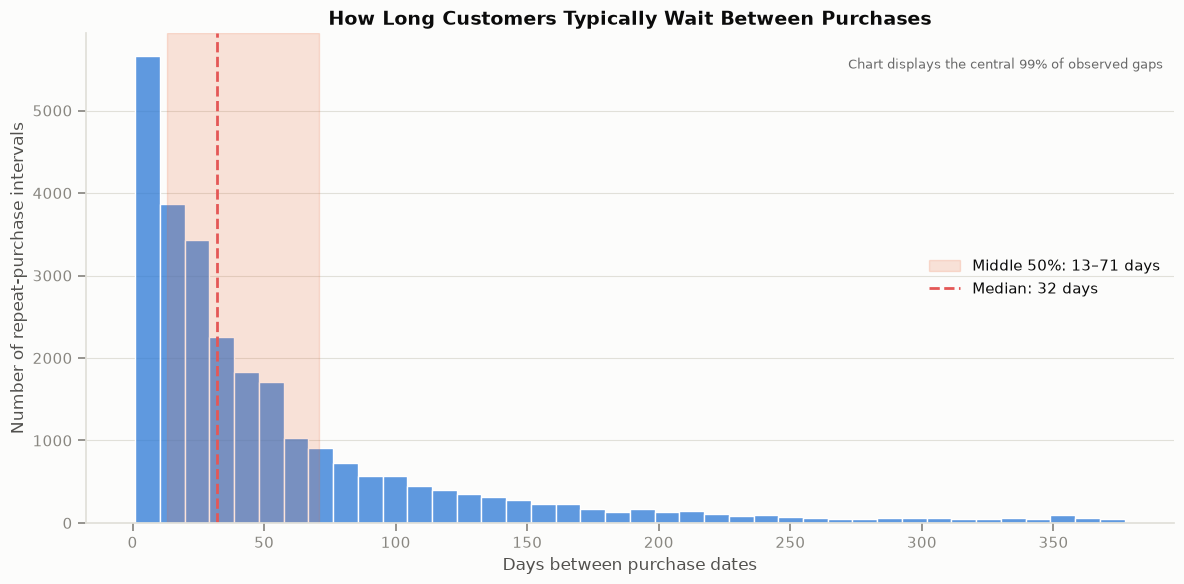

In [11]:
gap_upper_limit = daily_gap_df["GapDays"].quantile(0.99)

gap_plot_df = daily_gap_df[
    daily_gap_df["GapDays"] <= gap_upper_limit
].copy()

median_gap = daily_gap_df["GapDays"].median()
q1_gap = daily_gap_df["GapDays"].quantile(0.25)
q3_gap = daily_gap_df["GapDays"].quantile(0.75)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=gap_plot_df,
    x="GapDays",
    bins=40,
    color=BLUE,
    edgecolor="white",
    ax=ax,
)

ax.axvspan(
    q1_gap,
    q3_gap,
    color=ORANGE,
    alpha=0.18,
    label=f"Middle 50%: {q1_gap:.0f}–{q3_gap:.0f} days",
)

ax.axvline(
    median_gap,
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_gap:.0f} days",
)

ax.set_title(
    "How Long Customers Typically Wait Between Purchases",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Days between purchase dates")
ax.set_ylabel("Number of repeat-purchase intervals")
ax.legend(frameon=False)

ax.text(
    0.99,
    0.95,
    "Chart displays the central 99% of observed gaps",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color="dimgray",
)

style_ax(ax)
plt.tight_layout()
plt.show()

ECDF: the most useful horizon chart - An empirical cumulative distribution shows the percentage of observed repeat purchases completed within each number of days.
The ECDF answers:
What percentage of observed repeat purchases occurred within X days of the previous purchase?

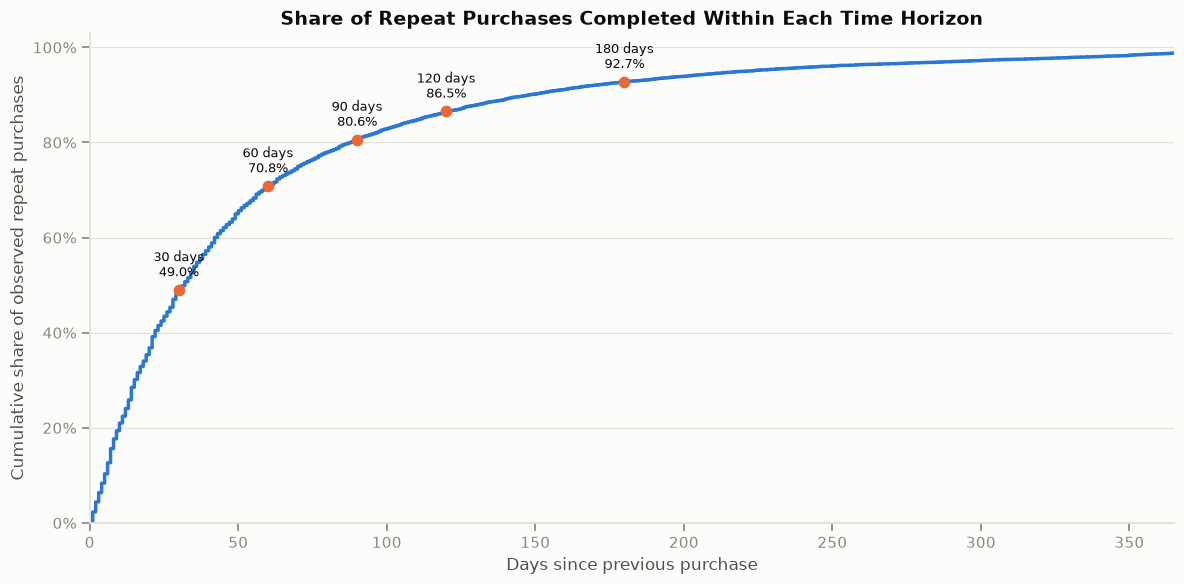

In [12]:
sorted_gaps = np.sort(daily_gap_df["GapDays"].to_numpy())
cumulative_share = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)

candidate_horizons = [30, 60, 90, 120, 180]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    sorted_gaps,
    cumulative_share,
    color=BLUE,
    linewidth=2.5,
)

for horizon in candidate_horizons:
    captured = (daily_gap_df["GapDays"] <= horizon).mean()

    ax.scatter(
        horizon,
        captured,
        color=ORANGE,
        s=55,
        zorder=3,
    )

    ax.annotate(
        f"{horizon} days\n{captured:.1%}",
        xy=(horizon, captured),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax.set_xlim(
    left=0,
    right=min(365, daily_gap_df["GapDays"].quantile(0.99)),
)
ax.set_ylim(0, 1.03)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_title(
    "Share of Repeat Purchases Completed Within Each Time Horizon",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Days since previous purchase")
ax.set_ylabel("Cumulative share of observed repeat purchases")

style_ax(ax)
plt.tight_layout()
plt.show()

Easy interpretation:
- A 30-day definition is too aggressive: 51% of observed repeat purchases took longer.
- A 60-day definition may still be early for almost 30% of repeat intervals.
- A 90-day definition covers approximately four out of five observed repeat intervals.
- A 120-day definition is safer but delays intervention.
- A 180-day definition is conservative but may identify churn too late for effective action.

Candidate-horizon comparison table

In [13]:
horizon_rows = []

for horizon in candidate_horizons:
    within_horizon = daily_gap_df["GapDays"] <= horizon

    horizon_rows.append({
        "HorizonDays": horizon,
        "ObservedGapsCaptured": within_horizon.mean(),
        "ObservedGapsBeyondHorizon": (~within_horizon).mean(),
        "GapsCapturedCount": int(within_horizon.sum()),
        "GapsBeyondCount": int((~within_horizon).sum()),
    })

horizon_summary = pd.DataFrame(horizon_rows)

display(
    horizon_summary.style.format({
        "ObservedGapsCaptured": "{:.1%}",
        "ObservedGapsBeyondHorizon": "{:.1%}",
        "GapsCapturedCount": "{:,}",
        "GapsBeyondCount": "{:,}",
    })
)

,HorizonDays,ObservedGapsCaptured,ObservedGapsBeyondHorizon,GapsCapturedCount,GapsBeyondCount
0,30,49.0%,51.0%,"13,190","13,749"
1,60,70.8%,29.2%,"19,079","7,860"
2,90,80.6%,19.4%,"21,710","5,229"
3,120,86.5%,13.5%,"23,309","3,630"
4,180,92.7%,7.3%,"24,982","1,957"


Customer-level typical gap - The interval table can be dominated by frequent purchasers because they contribute more gaps. Also calculate one typical gap per customer.

In [14]:
customer_gap_summary = (
    daily_gap_df
    .groupby("Customer ID")
    .agg(
        ObservedGaps=("GapDays", "size"),
        MedianGapDays=("GapDays", "median"),
        MeanGapDays=("GapDays", "mean"),
        MaxGapDays=("GapDays", "max"),
    )
    .reset_index()
)

display(customer_gap_summary.describe().round(1))

,Customer ID,ObservedGaps,MedianGapDays,MeanGapDays,MaxGapDays
count,4170.0,4170.0,4170.0,4170.0,4170.0
mean,15307.0,6.5,103.1,111.6,177.5
std,1697.8,11.2,105.3,102.4,121.3
min,12346.0,1.0,1.0,1.0,1.0
25%,13839.0,2.0,34.0,44.0,83.2
50%,15298.5,3.0,64.2,80.0,153.5
75%,16775.8,7.0,131.0,142.2,247.0
max,18287.0,246.0,714.0,714.0,714.0


Fields:
- ObservedGaps: number of completed gaps for the customer;
- MedianGapDays: their typical gap;
- MeanGapDays: their average gap;
- MaxGapDays: their longest observed gap.

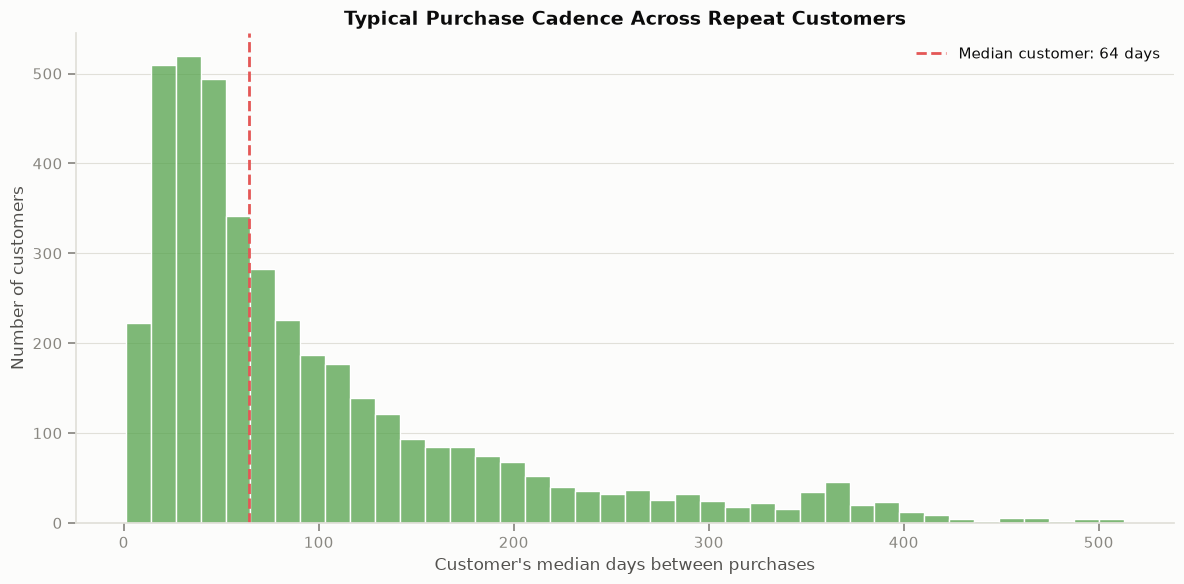

In [15]:
customer_gap_limit = customer_gap_summary["MedianGapDays"].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=customer_gap_summary[
        customer_gap_summary["MedianGapDays"] <= customer_gap_limit
    ],
    x="MedianGapDays",
    bins=40,
    color=GREEN,
    edgecolor="white",
    ax=ax,
)

overall_customer_median = customer_gap_summary["MedianGapDays"].median()

ax.axvline(
    overall_customer_median,
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Median customer: {overall_customer_median:.0f} days",
)

ax.set_title(
    "Typical Purchase Cadence Across Repeat Customers",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Customer's median days between purchases")
ax.set_ylabel("Number of customers")
ax.legend(frameon=False)

style_ax(ax)
plt.tight_layout()
plt.show()

This gives each customer equal influence, unlike the interval-level chart.

Purchasing cadence groups

In [16]:
customer_gap_summary["Cadence"] = pd.cut(
    customer_gap_summary["MedianGapDays"],
    bins=[-np.inf, 30, 60, 90, 180, np.inf],
    labels=[
        "Within 30 days",
        "31–60 days",
        "61–90 days",
        "91–180 days",
        "More than 180 days",
    ],
)

Cadence_summary = (
    customer_gap_summary["Cadence"]
    .value_counts(sort=False)
    .rename_axis("Cadence")
    .reset_index(name="Customers")
)

Cadence_summary["Share"] = (
    Cadence_summary["Customers"] / Cadence_summary["Customers"].sum()
)

display(Cadence_summary)

,Cadence,Customers,Share
0,Within 30 days,883,0.211751
1,31–60 days,1082,0.259472
2,61–90 days,624,0.149640
3,91–180 days,892,0.213909
4,More than 180 days,689,0.165228


Approximately 62.1% of repeat-day customers have a median gap of 90 days or less.
But 37.9% typically take longer than 90 days.
Meaning:
Customers do not all have the same natural purchasing schedule.

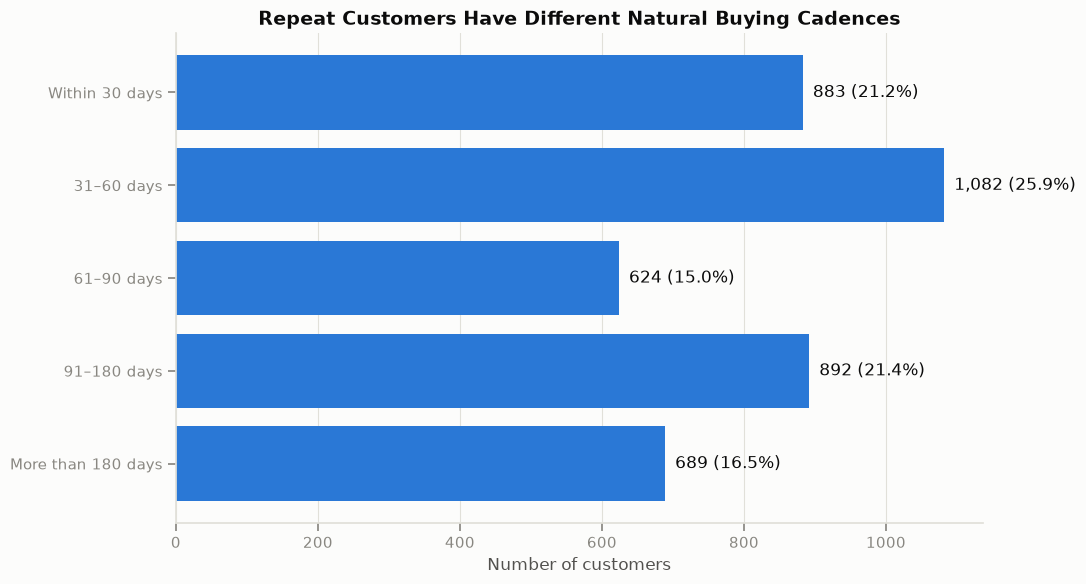

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    Cadence_summary["Cadence"],
    Cadence_summary["Customers"],
    color=BLUE,
)

ax.invert_yaxis()
ax.set_title(
    "Repeat Customers Have Different Natural Buying Cadences",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Number of customers")
ax.set_ylabel("")

for bar, customers, share in zip(
    bars,
    Cadence_summary["Customers"],
    Cadence_summary["Share"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {customers:,} ({share:.1%})",
        va="center",
    )

style_ax(ax, axis="x")
plt.tight_layout()
plt.show()

Check seasonality - The business sells gifts, so seasonality can materially affect purchase gaps.

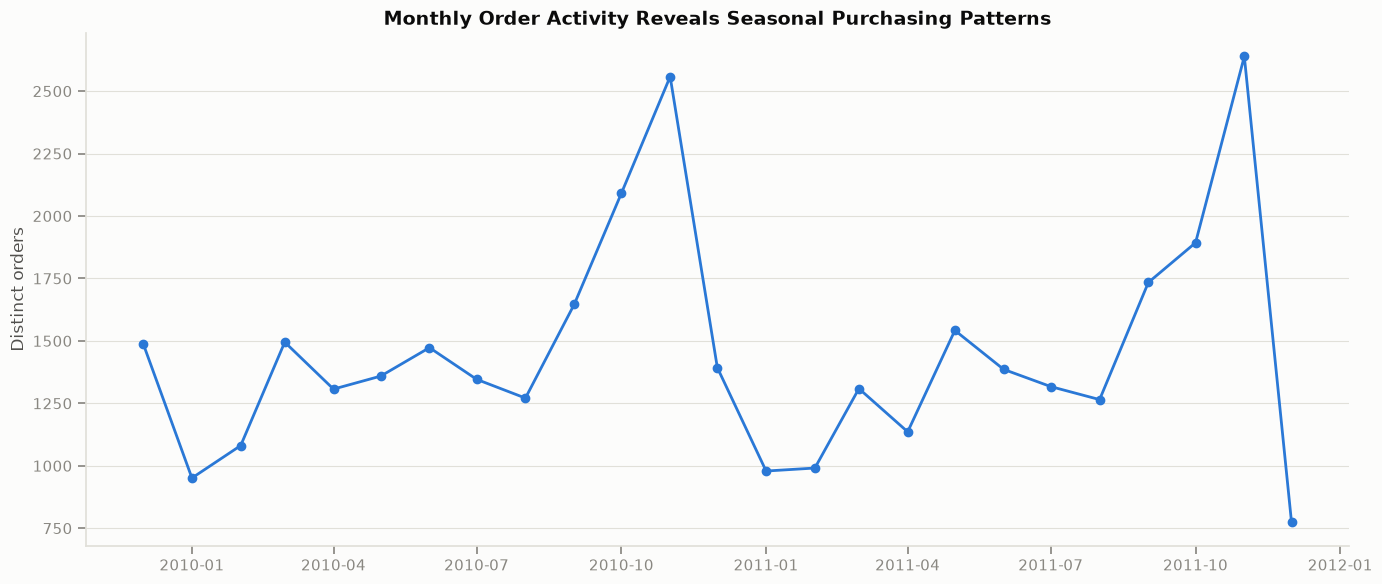

In [18]:
monthly_orders = (
    order_df
    .assign(Month=lambda x: x["PurchaseDate"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month")
    .agg(
        Orders=("Invoice", "nunique"),
        ActiveCustomers=("Customer ID", "nunique"),
        Revenue=("OrderValue", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_orders["Month"],
    monthly_orders["Orders"],
    color=BLUE,
    marker="o",
    linewidth=2,
)

ax.set_title(
    "Monthly Order Activity Reveals Seasonal Purchasing Patterns",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Distinct orders")

style_ax(ax)
plt.tight_layout()
plt.show()

inspect month-of-year:

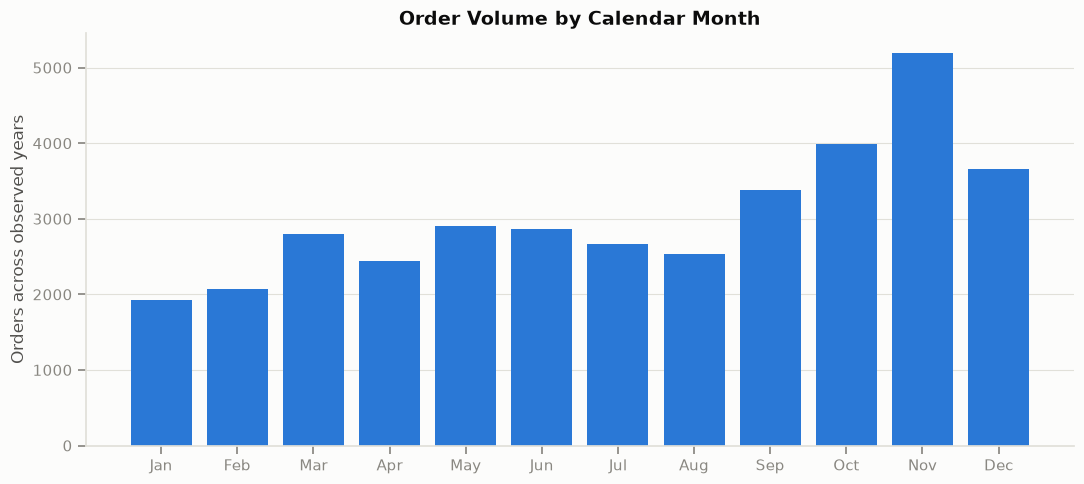

In [19]:
month_of_year = (
    order_df
    .assign(MonthNumber=lambda x: x["PurchaseDate"].dt.month)
    .groupby("MonthNumber")
    .agg(
        Orders=("Invoice", "nunique"),
        ActiveCustomers=("Customer ID", "nunique"),
    )
    .reset_index()
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    month_labels,
    month_of_year.set_index("MonthNumber")
    .reindex(range(1, 13))["Orders"],
    color=BLUE,
)

ax.set_title("Order Volume by Calendar Month", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Orders across observed years")

style_ax(ax)
plt.tight_layout()
plt.show()

Right-censoring check
The final observed purchase is not a completed interpurchase gap. We do not know when the customer would purchase after the dataset ends on 9 December 2011. If a customer’s last purchase was shortly before that date, you do not know whether they purchased again after the dataset ended.

In [20]:
dataset_end = purchases_df["InvoiceDate"].max()

customer_followup = (
    order_df
    .groupby("Customer ID")
    .agg(
        LastPurchase=("PurchaseDate", "max"),
        Orders=("Invoice", "nunique"),
    )
    .reset_index()
)

customer_followup["ObservedUntilDatasetEnd"] = (
    dataset_end - customer_followup["LastPurchase"]
).dt.days

display(
    customer_followup["ObservedUntilDatasetEnd"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .round(1)
)

count    5840.0
mean      199.2
std       208.5
min         0.0
25%        24.0
50%        94.0
75%       378.0
90%       530.0
95%       623.0
max       738.0
Name: ObservedUntilDatasetEnd, dtype: float64

Median days from final purchase to dataset end: 94 days. It describes how long each customer was observable after their final recorded purchase.

Check label availability for each candidate horizon - A snapshot after the latest fully observable date cannot be used for supervised training because its future outcome is incomplete.

In [21]:
label_availability = []

for horizon in candidate_horizons:
    latest_valid_snapshot = dataset_end - pd.Timedelta(days=horizon)

    label_availability.append({
        "HorizonDays": horizon,
        "DatasetEnd": dataset_end,
        "LatestFullyObservableSnapshot": latest_valid_snapshot,
    })

label_availability_df = pd.DataFrame(label_availability)

display(label_availability_df)

,HorizonDays,DatasetEnd,LatestFullyObservableSnapshot
0,30,2011-12-09 12:50:00,2011-11-09 12:50:00
1,60,2011-12-09 12:50:00,2011-10-10 12:50:00
2,90,2011-12-09 12:50:00,2011-09-10 12:50:00
3,120,2011-12-09 12:50:00,2011-08-11 12:50:00
4,180,2011-12-09 12:50:00,2011-06-12 12:50:00


For a 90-day target, a feature snapshot after 10 September cannot be used for supervised training because the dataset does not contain the complete following 90 days.
This calculation is correct and essential for preventing incomplete labels.

Optional segment comparison
Used the final segmentation only for exploratory interpretation and not to construct historical churn labels.

In [22]:
SEGMENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_segments.csv"
)

segments_df = pd.read_csv(
    SEGMENT_PATH,
    parse_dates=["SnapshotDate"],
)

segment_gap_df = customer_gap_summary.merge(
    segments_df[["Customer ID", "Segment"]],
    on="Customer ID",
    how="left",
)

segment_gap_summary = (
    segment_gap_df
    .groupby("Segment", observed=True)
    .agg(
        Customers=("Customer ID", "nunique"),
        MedianTypicalGap=("MedianGapDays", "median"),
        MeanTypicalGap=("MedianGapDays", "mean"),
    )
    .sort_values("MedianTypicalGap")
)

display(segment_gap_summary.round(1))

,Customers,MedianTypicalGap,MeanTypicalGap
Segment,,,
Exceptional high-value,62,11.0,38.0
Champions,1186,40.0,46.0
At-risk established,1402,82.0,104.6
Recent developing,968,98.5,150.6
Lapsed low-value,552,116.0,145.5


The segment comparison is descriptive only. These are final-snapshot segment labels and will not be used as historical churn features. Historical models will require segment assignments calculated independently at each snapshot.

Decision table - Create a concise table that combines statistical and operational considerations

In [23]:
decision_table = horizon_summary.copy()

decision_table["LatestUsableSnapshot"] = (
    dataset_end
    - pd.to_timedelta(decision_table["HorizonDays"], unit="D")
)

decision_table["BusinessInterpretation"] = decision_table[
    "HorizonDays"
].map({
    30: "Fast intervention, but likely flags normal customers too early",
    60: "Responsive, still strict for slower purchasers",
    90: "Balanced candidate for quarterly inactivity",
    120: "More conservative, intervention happens later",
    180: "High confidence inactivity, but limited time to recover customers",
})

display(
    decision_table.style.format({
        "ObservedGapsCaptured": "{:.1%}",
        "ObservedGapsBeyondHorizon": "{:.1%}",
        "GapsCapturedCount": "{:,}",
        "GapsBeyondCount": "{:,}",
    })
)

,HorizonDays,ObservedGapsCaptured,ObservedGapsBeyondHorizon,GapsCapturedCount,GapsBeyondCount,LatestUsableSnapshot,BusinessInterpretation
0,30,49.0%,51.0%,"13,190","13,749",2011-11-09 12:50:00,"Fast intervention, but likely flags normal customers too early"
1,60,70.8%,29.2%,"19,079","7,860",2011-10-10 12:50:00,"Responsive, still strict for slower purchasers"
2,90,80.6%,19.4%,"21,710","5,229",2011-09-10 12:50:00,Balanced candidate for quarterly inactivity
3,120,86.5%,13.5%,"23,309","3,630",2011-08-11 12:50:00,"More conservative, intervention happens later"
4,180,92.7%,7.3%,"24,982","1,957",2011-06-12 12:50:00,"High confidence inactivity, but limited time to recover customers"



### Recommendation
A provisional prediction horizon of 90 days is recommended.
A customer will be labelled as churned at a historical snapshot when they make no retained purchase during the following 90 days. This definition should be validated through historical snapshot testing before it is finalized.

### Evidence
- 80.6% of observed repeat-purchase intervals occur within 90 days.
- The median interval across all observed repeat purchases is 32 days.
- The typical repeat customer has a median purchase gap of approximately 64 days.
- 62.1% of repeat customers have a typical purchase cadence of 90 days or less.
- A 90-day horizon provides a practical balance: it avoids labelling customers inactive too quickly while leaving enough time for a retention campaign.
- A 60-day horizon would be too strict for many customers because 29.2% of observed repeat purchases occur after 60 days.
- A 120-day horizon captures more repeat purchases—86.5%—but delays intervention and reduces the number of historical snapshots with complete outcome windows.

### Trade-offs
A universal 90-day threshold makes the churn definition easier to explain, model and deploy. However, customers do not all purchase at the same rate:
- 37.9% of repeat customers have a typical purchase gap longer than 90 days.
- Gift purchases show seasonal behaviour, so some legitimate seasonal customers may be labelled churned under a fixed threshold.
- Shorter thresholds support earlier intervention but create more false churn labels.
- Longer thresholds reduce false churn labels but identify risk later and leave less labelled training data.

The model should therefore include features such as:
- the customer’s usual purchase cadence;
- recent changes in purchase frequency;
- customer tenure;
- one-time versus repeat-customer status;
- calendar month and seasonal purchasing behaviour;
- recent spending and order activity.

Also, 90 days should not be interpreted as:
“Everyone who waits 91 days has permanently left.”

Instead, the model target means:
“The customer did not make a retained purchase during the following 90-day prediction period.” That is a measurable outcome, not a claim that the relationship has permanently ended.

One-time customers will remain in the modelling population but will be identified separately. Their business problem is primarily failure to make a second purchase, rather than the loss of an established purchasing relationship.

### Right-censoring
The transaction data ends on 9 December 2011. With a 90-day prediction horizon, only snapshots on or before approximately 10 September 2011 can receive complete churn labels.
Later snapshots may eventually be used for scoring customers, but they cannot be used as labelled training examples because the full 90-day outcome period is unavailable.

### Leakage control
Every training row will be constructed as of a historical snapshot date.
Only information available on or before that snapshot will be used to:
- clean transactions;
- reconcile purchases and cancellations;
- calculate customer features;
- calculate RFM values;
- assign customer segments.
Purchases made during the following 90 days will be used only to create the churn label. Transactions, cancellations, RFM values and segment assignments occurring after the snapshot will never be used as model inputs.

### Final decision
The project will proceed with 90 days as the provisional churn horizon. Its suitability will be confirmed by creating historical customer snapshots and examining:
- churn-label balance;
- stability across different snapshot months;
- seasonal effects;
- differences between one-time and repeat customers;
- sensitivity against 60-, 120- and 180-day alternatives.

- analysed the time between customers’ distinct purchase days rather than choosing an arbitrary churn threshold. Half of observed repeat purchases occurred within 32 days, 75% within 71 days, and approximately 80% within 88 days. I therefore selected 90 days as an initial horizon. It was long enough to cover most normal repeat-purchase intervals, short enough for the business to intervene, and left more usable historical training data than a 120- or 180-day horizon. I documented the trade-off that some slower and seasonal customers naturally take longer, so customer cadence and seasonality must be included as features. I then planned to validate 90 days against alternative horizons using historical snapshots before treating it as final

**Knowledge to help understanding the below cells**
- Think of Snapshot literally as the word suggests — a freeze-frame. A snapshot date is the moment you pretend is "today," and you deliberately blind yourself to everything that happens after it. Every feature you compute has to be answerable using only data up to that frozen moment, as if the future hadn't happened yet.

- Why this matters here specifically: in segmentation, there's only one honest snapshot — the actual last day in the dataset (2011-12-09 + 1 day, which is what build_segmentation_table.py uses as snapshot_date). That makes sense there, because segmentation is answering "who is this customer right now," and "right now" really is the end of your data.

- Churn is different, and this is the part worth sitting with: to know whether someone churned, you need to check what they did after the snapshot. If your snapshot is the very last day of the dataset, there is no "after" left to check — you'd be asking a question the data can't answer. So for churn, the snapshot has to be a date you deliberately move backward in time, into the middle of your history, specifically so that a real "after" still exists for you to look at and see whether they came back or not

# Historical Snapshot Label Sensitivity

A historical snapshot recreates what the business would have known on a
particular date.

For every snapshot:

- the previous 180 days determine which customers are eligible and describe
  their known behaviour;
- purchases on or after the snapshot are never used as features;
- the following 30–180 days are used only to create churn outcomes;
- only snapshots with a completely observable future window are retained.

The same snapshot dates and eligible customers are used across all candidate
horizons. This makes churn-rate comparisons fair.

In [24]:
"""
What it does
This cell establishes the business rules for the experiment.
It says:
- use the customer’s previous 180 days of activity;
- test five possible future periods;
- the longest future period is 180 days.

We identify the time boundaries of the data
 so that we do not create historical examples 
 requiring information outside the period we actually observe.

We look at six months of customer history 
and test how the definition of churn changes 
when customers are given between 30 and 180 days to return.
"""
CANDIDATE_HORIZONS = [30, 60, 90, 120, 180]

# A customer must have purchased in this period to be considered
# currently addressable at the snapshot.
ELIGIBILITY_LOOKBACK_DAYS = 180

# Use the largest horizon to ensure every snapshot has a complete future
# period for all candidate definitions.
MAX_HORIZON = max(CANDIDATE_HORIZONS)

purchase_days = (
    daily_purchase_df[
        ["Customer ID", "PurchaseDay", "DailyValue", "Invoices"]
    ]
    .copy()
    .sort_values(["Customer ID", "PurchaseDay"])
    .reset_index(drop=True)
)

purchase_days["PurchaseDay"] = pd.to_datetime(
    purchase_days["PurchaseDay"]
).dt.normalize()

dataset_start = purchase_days["PurchaseDay"].min()
dataset_end = purchase_days["PurchaseDay"].max()

# First snapshot needs a complete 180-day historical observation period.
first_valid_snapshot = (
    dataset_start + pd.Timedelta(days=ELIGIBILITY_LOOKBACK_DAYS)
)

# Last snapshot needs a complete future window for the longest horizon.
last_valid_snapshot = (
    dataset_end - pd.Timedelta(days=MAX_HORIZON)
)

# Monthly snapshots on the first day of each month. freq="MS" means month start.
snapshot_dates = pd.date_range(
    start=first_valid_snapshot,
    end=last_valid_snapshot,
    freq="MS", 
)

print(f"Dataset period: {dataset_start.date()} to {dataset_end.date()}")
print(
    "Historical observation window:",
    f"{ELIGIBILITY_LOOKBACK_DAYS} days",
)
print(f"Candidate horizons: {CANDIDATE_HORIZONS}")
print(f"Common snapshot period: {snapshot_dates.min().date()} to {snapshot_dates.max().date()}")
print(f"Number of monthly snapshots: {len(snapshot_dates)}")

Dataset period: 2009-12-01 to 2011-12-09
Historical observation window: 180 days
Candidate horizons: [30, 60, 90, 120, 180]
Common snapshot period: 2010-06-01 to 2011-06-01
Number of monthly snapshots: 13


Why use a common snapshot period? If 30-day labels used later snapshots than 180-day labels, differences in churn prevalence could be caused by seasonality rather than the horizon itself.

### Build customer-snapshot labels

"""
this selects the customer activity needed for churn labelling:
- customer;
- purchase date;
- purchase value;
- number of invoices.
Multiple invoices placed by one customer on the same day 
have already been combined in daily_purchase_df.

We reduce the transaction data to one customer activity record per 
purchase day so that several invoices placed during 
the same shopping session do not look like several separate customer returns.
"""

def build_snapshot_labels(
    purchase_days: pd.DataFrame,
    snapshot_dates,
    horizons,
    observation_days: int = 180,
) -> pd.DataFrame:
    """
    Build one row per eligible customer, snapshot and prediction horizon.

    Eligibility:
        At least one retained purchase during the historical observation
        window [snapshot - observation_days, snapshot).

    Label:
        Churn = 1 when the customer makes no retained purchase during
        [snapshot, snapshot + horizon).

        Churn = 0 when at least one retained purchase occurs in that period.

    Boundary convention:
        Purchases before the snapshot are historical inputs.
        Purchases on the snapshot date belong to the future label period.
    """
    required_columns = {
        "Customer ID",
        "PurchaseDay",
        "DailyValue",
        "Invoices",
    }

    missing_columns = required_columns.difference(
        purchase_days.columns
    )

    if missing_columns:
        raise ValueError(
            f"purchase_days is missing columns: {sorted(missing_columns)}"
        )

    purchase_days = purchase_days.copy()
    purchase_days["PurchaseDay"] = pd.to_datetime(
        purchase_days["PurchaseDay"]
    ).dt.normalize()

    output_frames = []

    for snapshot_date in pd.to_datetime(snapshot_dates):
        snapshot_date = pd.Timestamp(snapshot_date).normalize()
        observation_start = (
            snapshot_date - pd.Timedelta(days=observation_days)
        )

        # Information available strictly before the snapshot.
        history = purchase_days[
            (purchase_days["PurchaseDay"] >= observation_start)
            & (purchase_days["PurchaseDay"] < snapshot_date)
        ].copy()

        if history.empty:
            continue

        # One historical feature row per eligible customer.
        eligible = (
            history
            .groupby("Customer ID", as_index=False)
            .agg(
                HistoryPurchaseDays=("PurchaseDay", "nunique"),
                HistoryInvoices=("Invoices", "sum"),
                HistoryMonetary=("DailyValue", "sum"),
                FirstPurchaseInWindow=("PurchaseDay", "min"),
                LastPurchaseBeforeSnapshot=("PurchaseDay", "max"),
            )
        )

        eligible["ObservationStart"] = observation_start
        eligible["SnapshotDate"] = snapshot_date
        
        eligible["RecencyAtSnapshot"] = (
            snapshot_date
            - eligible["LastPurchaseBeforeSnapshot"]
        ).dt.days

        eligible["ObservedTenureInWindow"] = (
            eligible["LastPurchaseBeforeSnapshot"]
            - eligible["FirstPurchaseInWindow"]
        ).dt.days

        eligible["CustomerStageAtSnapshot"] = np.where(
            eligible["HistoryPurchaseDays"] == 1,
            "One purchase day",
            "Repeat purchase days",
        )

        # Find the first purchase on or after the snapshot.
        future_activity = purchase_days[
            purchase_days["PurchaseDay"] >= snapshot_date
        ]

        next_purchase = (
            future_activity
            .groupby("Customer ID", as_index=False)
            .agg(
                NextPurchaseDate=("PurchaseDay", "min")
            )
        )

        eligible = eligible.merge(
            next_purchase,
            on="Customer ID",
            how="left",
            validate="one_to_one",
        )

        eligible["DaysToNextPurchase"] = (
            eligible["NextPurchaseDate"]
            - eligible["SnapshotDate"]
        ).dt.days

        for horizon in horizons:
            labelled = eligible.copy()

            labelled["HorizonDays"] = horizon
            labelled["LabelEndDate"] = (
                labelled["SnapshotDate"]
                + pd.Timedelta(days=horizon)
            )

            labelled["ReturnedWithinHorizon"] = (
                labelled["NextPurchaseDate"].notna()
                & (
                    labelled["NextPurchaseDate"]
                    < labelled["LabelEndDate"]
                )
            ).astype("int8")

            labelled["Churn"] = (
                1 - labelled["ReturnedWithinHorizon"]
            ).astype("int8")

            output_frames.append(labelled)

    if not output_frames:
        raise ValueError(
            "No snapshot labels were created. Check the dates and "
            "observation window."
        )

    snapshot_labels = pd.concat(
        output_frames,
        ignore_index=True,
    )

    return snapshot_labels

### Build customer-snapshot labels

The reusable implementation is stored in
`customer_intelligence/churn/labels.py`.

The function:

- identifies customers active during the observation window;
- summarizes information available before each snapshot;
- finds the next purchase after the snapshot;
- creates forward-looking churn labels;
- rejects snapshots without a complete future label period.

The notebook imports this function so that the analysis, tests and future
pipeline use the same label definition.

In [25]:
snapshot_labels = build_snapshot_labels(
    purchase_days=purchase_days,
    snapshot_dates=snapshot_dates,
    horizons=CANDIDATE_HORIZONS,
    observation_days=ELIGIBILITY_LOOKBACK_DAYS,
)

print(f"Customer-snapshot-horizon rows: {len(snapshot_labels):,}")
print(
    "Unique customers:",
    f"{snapshot_labels['Customer ID'].nunique():,}",
)
print(
    "Unique snapshots:",
    snapshot_labels["SnapshotDate"].nunique(),
)

display(snapshot_labels.tail())

Customer-snapshot-horizon rows: 197,865
Unique customers: 4,885
Unique snapshots: 13


,Customer ID,HistoryPurchaseDays,HistoryInvoices,HistoryMonetary,FirstPurchaseInWindow,LastPurchaseBeforeSnapshot,SnapshotDate,ObservationStart,RecencyAtSnapshot,ObservedTenureInWindow,CustomerStageAtSnapshot,NextPurchaseDate,DaysToNextPurchase,HorizonDays,LabelEndDate,ReturnedWithinHorizon,Churn
197860,18272,2,2,965.94,2011-04-07,2011-04-28,2011-06-01,2010-12-03,34,21,Repeat purchase days,2011-07-12,41.0,180,2011-11-28,1,0
197861,18273,1,1,51.00,2011-03-27,2011-03-27,2011-06-01,2010-12-03,66,0,One purchase day,2011-09-05,96.0,180,2011-11-28,1,0
197862,18280,1,1,180.60,2011-03-07,2011-03-07,2011-06-01,2010-12-03,86,0,One purchase day,NaT,NaN,180,2011-11-28,0,1
197863,18283,5,5,533.10,2011-01-06,2011-05-23,2011-06-01,2010-12-03,9,137,Repeat purchase days,2011-06-14,13.0,180,2011-11-28,1,0
197864,18287,1,1,765.28,2011-05-22,2011-05-22,2011-06-01,2010-12-03,10,0,One purchase day,2011-10-12,133.0,180,2011-11-28,1,0


This creates one row per eligible customer and calculates:
- purchase days in the previous 180 days;
- invoices in the previous 180 days;
- monetary value in the previous 180 days;
- first purchase in the window;
- last purchase before the snapshot.
Stakeholder meaning:
We create a customer profile using only information the business would have possessed on the prediction date.

**Column Meanings**
| Column | Meaning |
|---|---|
| `Customer ID` | Customer being evaluated |
| `SnapshotDate` | Date on which a prediction would have been made |
| `ObservationStart` | Beginning of available historical window |
| `HistoryPurchaseDays` | Active purchase days in the previous 180 days |
| `HistoryInvoices` | Invoices in the previous 180 days |
| `HistoryMonetary` | Retained value in the previous 180 days |
| `RecencyAtSnapshot` | Days since last known purchase |
| `HorizonDays` | Future period being tested |
| `NextPurchaseDate` | First purchase on or after the snapshot |
| `ReturnedWithinHorizon` | 1 if the customer bought during the horizon |
| `Churn` | 1 if no purchase occurred during the horizon |

eg
- SnapshotDate = 2011-01-01
- HorizonDays = 90
- Churn = 1

Based on activity available before 1 January, this customer made no retained purchase from 1 January through the following 90-day period.

A customer is eligible if they made at least one retained purchase during the previous 180 days.
The snapshot date is excluded from history because activity on that date belongs to the future outcome period.

Stakeholder meaning:

We score customers with evidence of a recent commercial relationship. Customers who have already been inactive for years are not repeatedly treated as new churn cases every month.

Without this rule, long-dormant customers would appear as churned at every snapshot and dominate the training data.

***Add data-quality tests** - Because snapshots occur at midnight and historical purchases must be before the snapshot, minimum Recency should be at least one calendar day.

In [26]:
expected_pairs = (
    snapshot_labels[
        ["Customer ID", "SnapshotDate"]
    ]
    .drop_duplicates()
    .shape[0]
    * len(CANDIDATE_HORIZONS)
)

assert len(snapshot_labels) == expected_pairs

assert not snapshot_labels[
    ["Customer ID", "SnapshotDate", "HorizonDays"]
].duplicated().any()

assert snapshot_labels["Churn"].isin([0, 1]).all()

assert snapshot_labels[
    "ReturnedWithinHorizon"
].isin([0, 1]).all()

assert (
    snapshot_labels["Churn"]
    + snapshot_labels["ReturnedWithinHorizon"]
    == 1
).all()

assert (
    snapshot_labels["LastPurchaseBeforeSnapshot"]
    < snapshot_labels["SnapshotDate"]
).all()

assert (
    snapshot_labels["LabelEndDate"]
    <= dataset_end
).all()

assert (
    snapshot_labels["RecencyAtSnapshot"]
    >= 1
).all()

assert (
    snapshot_labels["HistoryPurchaseDays"]
    >= 1
).all()

print("All historical snapshot QA checks passed.")

All historical snapshot QA checks passed.


Check that customers are identical across horizons - The comparison should use the same customer-snapshot population for every horizon.

In [27]:
population_check = (
    snapshot_labels
    .groupby("HorizonDays")
    .agg(
        Rows=("Customer ID", "size"),
        Customers=("Customer ID", "nunique"),
        Snapshots=("SnapshotDate", "nunique"),
    )
)

display(population_check)

assert population_check["Rows"].nunique() == 1
assert population_check["Snapshots"].nunique() == 1

print("All horizons use the same eligible customer-snapshot population.")

,Rows,Customers,Snapshots
HorizonDays,,,
30,39573,4885,13
60,39573,4885,13
90,39573,4885,13
120,39573,4885,13
180,39573,4885,13


All horizons use the same eligible customer-snapshot population.


A customer is labelled churned when they make no retained purchase during the 90 days following a historical snapshot.

Compare overall churn prevalence

In [28]:
label_prevalence = (
    snapshot_labels
    .groupby("HorizonDays", as_index=False)
    .agg(
        CustomerSnapshots=("Churn", "size"),
        Churned=("Churn", "sum"),
        ChurnRate=("Churn", "mean"),
        ReturnRate=("ReturnedWithinHorizon", "mean"),
    )
)

display(
    label_prevalence.style.format({
        "CustomerSnapshots": "{:,}",
        "Churned": "{:,}",
        "ChurnRate": "{:.1%}",
        "ReturnRate": "{:.1%}",
    })
)

,HorizonDays,CustomerSnapshots,Churned,ChurnRate,ReturnRate
0,30,"39,573","29,503",74.6%,25.4%
1,60,"39,573","24,096",60.9%,39.1%
2,90,"39,573","20,711",52.3%,47.7%
3,120,"39,573","18,293",46.2%,53.8%
4,180,"39,573","15,135",38.2%,61.8%


Longer prediction horizon
→ more time for a customer to return
→ lower churn prevalence

In [29]:
assert (
    label_prevalence
    .sort_values("HorizonDays")["ChurnRate"]
    .is_monotonic_decreasing
)

print("Churn prevalence decreases as the prediction horizon increases.")

Churn prevalence decreases as the prediction horizon increases.


**Add confidence intervals**

The same customer can appear in several snapshots, so these intervals are descriptive rather than formal independent-sample inference. They are still useful for showing the scale of uncertainty.

In [30]:
def wilson_interval(successes, observations, z=1.96):
    """
    Wilson binomial confidence interval.

    Here, 'successes' means churned customer-snapshot rows.
    """
    if observations == 0:
        return np.nan, np.nan

    proportion = successes / observations
    denominator = 1 + (z**2 / observations)

    centre = (
        proportion
        + z**2 / (2 * observations)
    ) / denominator

    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / observations
            + z**2 / (4 * observations**2)
        )
        / denominator
    )

    return centre - margin, centre + margin

In [31]:
intervals = label_prevalence.apply(
    lambda row: wilson_interval(
        successes=row["Churned"],
        observations=row["CustomerSnapshots"],
    ),
    axis=1,
)

label_prevalence[
    ["ChurnRateLower", "ChurnRateUpper"]
] = pd.DataFrame(
    intervals.tolist(),
    index=label_prevalence.index,
)

display(
    label_prevalence.style.format({
        "CustomerSnapshots": "{:,}",
        "Churned": "{:,}",
        "ChurnRate": "{:.1%}",
        "ReturnRate": "{:.1%}",
        "ChurnRateLower": "{:.1%}",
        "ChurnRateUpper": "{:.1%}",
    })
)

,HorizonDays,CustomerSnapshots,Churned,ChurnRate,ReturnRate,ChurnRateLower,ChurnRateUpper
0,30,"39,573","29,503",74.6%,25.4%,74.1%,75.0%
1,60,"39,573","24,096",60.9%,39.1%,60.4%,61.4%
2,90,"39,573","20,711",52.3%,47.7%,51.8%,52.8%
3,120,"39,573","18,293",46.2%,53.8%,45.7%,46.7%
4,180,"39,573","15,135",38.2%,61.8%,37.8%,38.7%


Stakeholder visual: churn rate by horizon

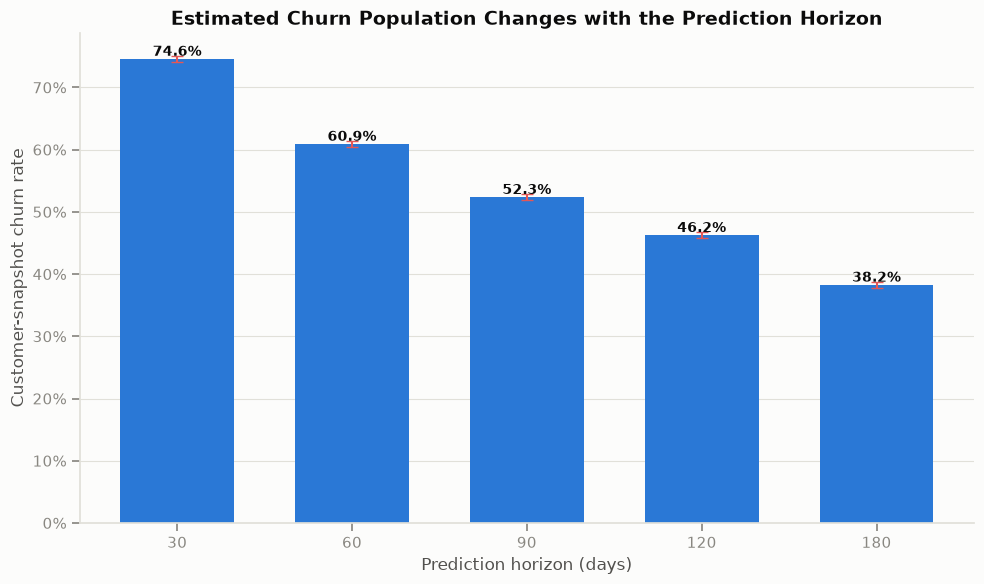

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    label_prevalence["HorizonDays"].astype(str),
    label_prevalence["ChurnRate"],
    color=BLUE,
    width=0.65,
)

ax.errorbar(
    x=np.arange(len(label_prevalence)),
    y=label_prevalence["ChurnRate"],
    yerr=[
        (
            label_prevalence["ChurnRate"]
            - label_prevalence["ChurnRateLower"]
        ),
        (
            label_prevalence["ChurnRateUpper"]
            - label_prevalence["ChurnRate"]
        ),
    ],
    fmt="none",
    ecolor=RED,
    capsize=4,
    linewidth=1.5,
)

for bar, rate in zip(
    bars,
    label_prevalence["ChurnRate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
    )

ax.set_title(
    "Estimated Churn Population Changes with the Prediction Horizon",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Prediction horizon (days)")
ax.set_ylabel("Customer-snapshot churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))

style_ax(ax)
plt.tight_layout()
plt.show()

Short horizons classify more customers as churned because customers have less time to return. Longer horizons create more confident inactivity labels, but the business learns about risk later.

**Compare churn rates over historical snapshots**

Overall prevalence can hide major seasonal changes.

In [33]:
monthly_prevalence = (
    snapshot_labels
    .groupby(
        ["SnapshotDate", "HorizonDays"],
        as_index=False,
    )
    .agg(
        EligibleCustomers=("Customer ID", "nunique"),
        ChurnRate=("Churn", "mean"),
    )
)

display(monthly_prevalence.head())

,SnapshotDate,HorizonDays,EligibleCustomers,ChurnRate
0,2010-06-01,30,2645,0.711909
1,2010-06-01,60,2645,0.582231
2,2010-06-01,90,2645,0.500189
3,2010-06-01,120,2645,0.427599
4,2010-06-01,180,2645,0.284688


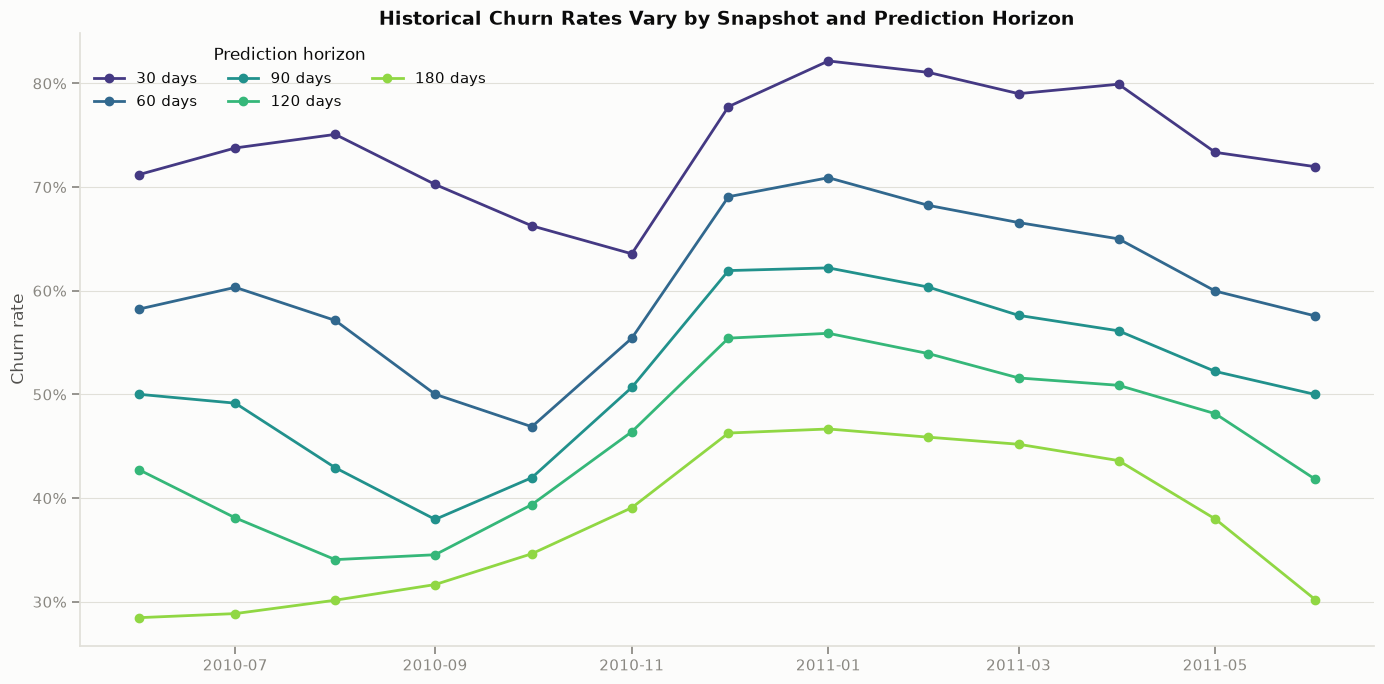

In [34]:
fig, ax = plt.subplots(figsize=(14, 7))

palette = sns.color_palette(
    "viridis",
    n_colors=len(CANDIDATE_HORIZONS),
)

for color, horizon in zip(
    palette,
    CANDIDATE_HORIZONS,
):
    horizon_data = monthly_prevalence[
        monthly_prevalence["HorizonDays"] == horizon
    ]

    ax.plot(
        horizon_data["SnapshotDate"],
        horizon_data["ChurnRate"],
        marker="o",
        linewidth=2,
        color=color,
        label=f"{horizon} days",
    )

ax.set_title(
    "Historical Churn Rates Vary by Snapshot and Prediction Horizon",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(
    title="Prediction horizon",
    frameon=False,
    ncol=3,
)

style_ax(ax)
plt.tight_layout()
plt.show()

This chart helps answer:
- Is a particular threshold stable over time?
- Is the churn rate strongly seasonal?
- Does one snapshot produce an abnormal result?
- Would the model face changing class balance after deployment?

**Heatmap for horizon sensitivity**

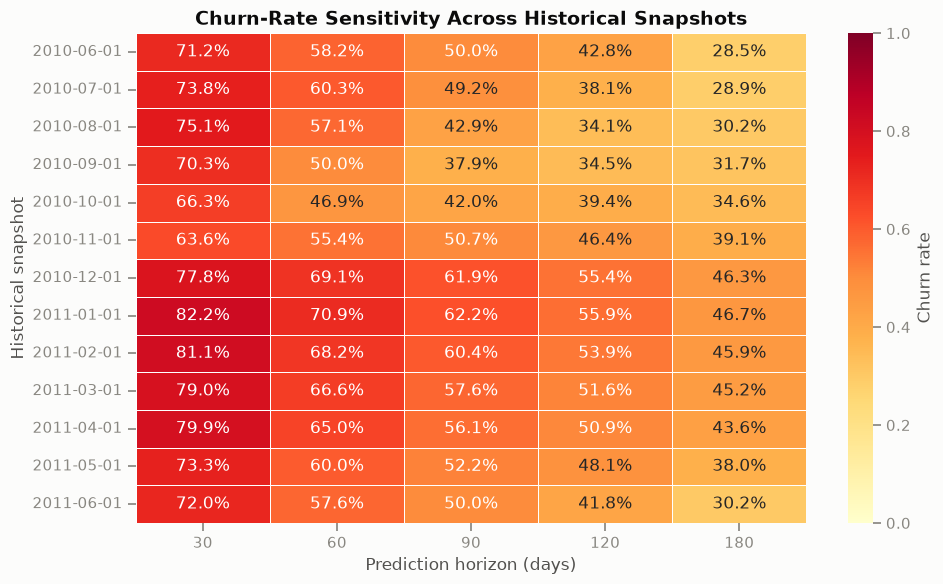

In [35]:
prevalence_matrix = (
    monthly_prevalence
    .pivot(
        index="SnapshotDate",
        columns="HorizonDays",
        values="ChurnRate",
    )
)

fig, ax = plt.subplots(
    figsize=(10, max(6, len(prevalence_matrix) * 0.45))
)

sns.heatmap(
    prevalence_matrix,
    annot=True,
    fmt=".1%",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Churn rate"},
    ax=ax,
)

ax.set_title(
    "Churn-Rate Sensitivity Across Historical Snapshots",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Prediction horizon (days)")
ax.set_ylabel("Historical snapshot")
ax.set_yticklabels(
    [
        date.strftime("%Y-%m-%d")
        for date in prevalence_matrix.index
    ],
    rotation=0,
)

plt.tight_layout()
plt.show()

The 90-day churn rate ranges from: 37.9% to 62.2% across historical snapshots.

The lowest rates occur around snapshots whose future periods include stronger late-year purchasing activity. Rates rise around December and January snapshots.
This means:
- the target is not perfectly stable across time;
- random train/test splitting would be inappropriate;
- calendar and seasonal features should be included;
- validation must use later dates than training;
- model performance should be reported by snapshot month.
This variation is expected for a gift retailer and is not automatically a problem.

Compare one-purchase and repeat customers

In [36]:
stage_prevalence = (
    snapshot_labels
    .groupby(
        ["HorizonDays", "CustomerStageAtSnapshot"],
        as_index=False,
    )
    .agg(
        CustomerSnapshots=("Churn", "size"),
        ChurnRate=("Churn", "mean"),
    )
)

display(
    stage_prevalence.style.format({
        "CustomerSnapshots": "{:,}",
        "ChurnRate": "{:.1%}",
    })
)

,HorizonDays,CustomerStageAtSnapshot,CustomerSnapshots,ChurnRate
0,30,One purchase day,"18,979",86.8%
1,30,Repeat purchase days,"20,594",63.2%
2,60,One purchase day,"18,979",77.1%
3,60,Repeat purchase days,"20,594",46.0%
4,90,One purchase day,"18,979",69.7%
5,90,Repeat purchase days,"20,594",36.3%
6,120,One purchase day,"18,979",63.8%
7,120,Repeat purchase days,"20,594",30.0%
8,180,One purchase day,"18,979",55.3%
9,180,Repeat purchase days,"20,594",22.5%


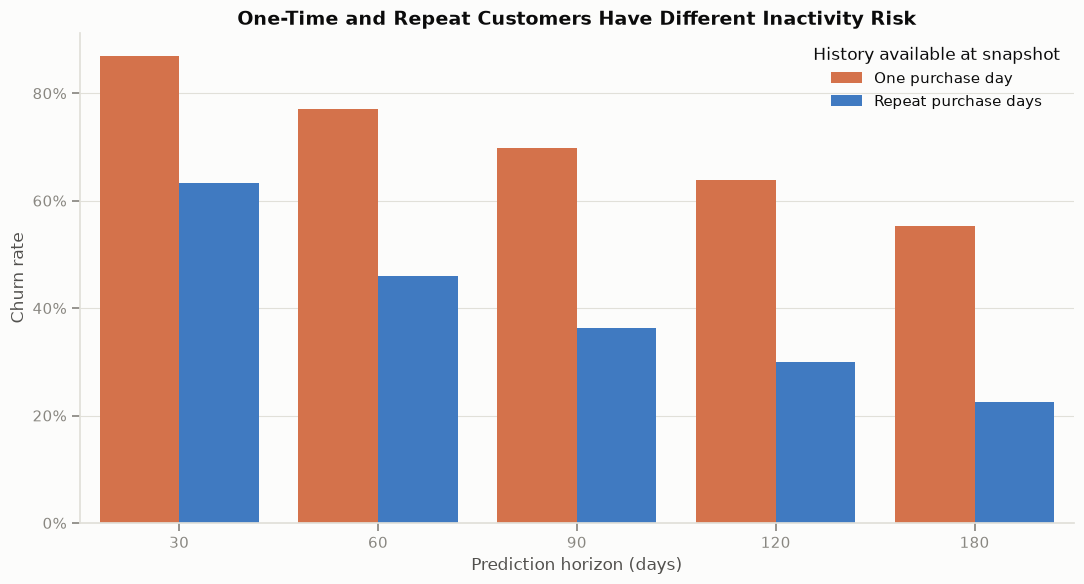

In [37]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=stage_prevalence,
    x="HorizonDays",
    y="ChurnRate",
    hue="CustomerStageAtSnapshot",
    palette={
        "One purchase day": ORANGE,
        "Repeat purchase days": BLUE,
    },
    ax=ax,
)

ax.set_title(
    "One-Time and Repeat Customers Have Different Inactivity Risk",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Prediction horizon (days)")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(
    title="History available at snapshot",
    frameon=False,
)

style_ax(ax)
plt.tight_layout()
plt.show()

If one-purchase customers have a substantially higher churn rate, that supports treating them as a separate lifecycle problem.

**Inspect the provisional 90-day label**

In [38]:
PROVISIONAL_HORIZON = 90

labels_90 = snapshot_labels[
    snapshot_labels["HorizonDays"] == PROVISIONAL_HORIZON
].copy()

print(f"Rows for {PROVISIONAL_HORIZON}-day model: {len(labels_90):,}")
print(f"Unique customers: {labels_90['Customer ID'].nunique():,}")
print(f"Snapshots: {labels_90['SnapshotDate'].nunique()}")
print(f"Churn rate: {labels_90['Churn'].mean():.1%}")

display(
    labels_90[
        [
            "Customer ID",
            "SnapshotDate",
            "HistoryPurchaseDays",
            "HistoryInvoices",
            "HistoryMonetary",
            "RecencyAtSnapshot",
            "NextPurchaseDate",
            "DaysToNextPurchase",
            "Churn",
        ]
    ].head(10)
)

Rows for 90-day model: 39,573
Unique customers: 4,885
Snapshots: 13
Churn rate: 52.3%


,Customer ID,SnapshotDate,HistoryPurchaseDays,HistoryInvoices,HistoryMonetary,RecencyAtSnapshot,NextPurchaseDate,DaysToNextPurchase,Churn
5290,12346,2010-06-01,1,1,27.05,91,2010-06-28,27.0,0
5291,12349,2010-06-01,1,1,1068.52,33,2010-10-28,149.0,1
5292,12355,2010-06-01,1,1,488.21,11,2011-05-09,342.0,1
5293,12358,2010-06-01,1,1,1429.83,175,2010-06-07,6.0,0
5294,12359,2010-06-01,4,4,1428.23,70,2010-06-22,21.0,0
5295,12360,2010-06-01,2,2,620.04,7,2010-11-12,164.0,1
5296,12361,2010-06-01,2,2,177.35,23,2010-09-03,94.0,1
5297,12366,2010-06-01,1,1,500.24,77,NaT,NaN,1
5298,12368,2010-06-01,1,1,917.70,72,NaT,NaN,1
5299,12369,2010-06-01,1,1,308.32,85,2010-09-16,107.0,1


**Inspect class balance by snapshot**

In [39]:
labels_90_by_snapshot = (
    labels_90
    .groupby("SnapshotDate", as_index=False)
    .agg(
        EligibleCustomers=("Customer ID", "nunique"),
        ChurnedCustomers=("Churn", "sum"),
        ChurnRate=("Churn", "mean"),
    )
)

display(
    labels_90_by_snapshot.style.format({
        "EligibleCustomers": "{:,}",
        "ChurnedCustomers": "{:,}",
        "ChurnRate": "{:.1%}",
    })
)

,SnapshotDate,EligibleCustomers,ChurnedCustomers,ChurnRate
0,2010-06-01 00:00:00,"2,645","1,323",50.0%
1,2010-07-01 00:00:00,"2,730","1,342",49.2%
2,2010-08-01 00:00:00,"2,809","1,206",42.9%
3,2010-09-01 00:00:00,"2,817","1,069",37.9%
4,2010-10-01 00:00:00,"2,890","1,213",42.0%
5,2010-11-01 00:00:00,"3,181","1,612",50.7%
6,2010-12-01 00:00:00,"3,453","2,139",61.9%
7,2011-01-01 00:00:00,"3,392","2,110",62.2%
8,2011-02-01 00:00:00,"3,337","2,014",60.4%
9,2011-03-01 00:00:00,"3,330","1,919",57.6%


A large change between snapshots may reflect holiday seasonality or changes in the customer population.

Optional prevalence by recency at snapshot : This checks whether the churn definition behaves logically.

In [40]:
labels_90["RecencyBand"] = pd.cut(
    labels_90["RecencyAtSnapshot"],
    bins=[0, 30, 60, 90, 120, 180],
    include_lowest=True,
    labels=[
        "0–30 days",
        "31–60 days",
        "61–90 days",
        "91–120 days",
        "121–180 days",
    ],
)

recency_prevalence = (
    labels_90
    .groupby(
        "RecencyBand",
        observed=True,
        as_index=False,
    )
    .agg(
        CustomerSnapshots=("Churn", "size"),
        ChurnRate=("Churn", "mean"),
    )
)

display(
    recency_prevalence.style.format({
        "CustomerSnapshots": "{:,}",
        "ChurnRate": "{:.1%}",
    })
)

,RecencyBand,CustomerSnapshots,ChurnRate
0,0–30 days,"13,145",36.6%
1,31–60 days,"8,078",49.0%
2,61–90 days,"6,172",58.0%
3,91–120 days,"4,795",64.5%
4,121–180 days,"7,383",71.3%


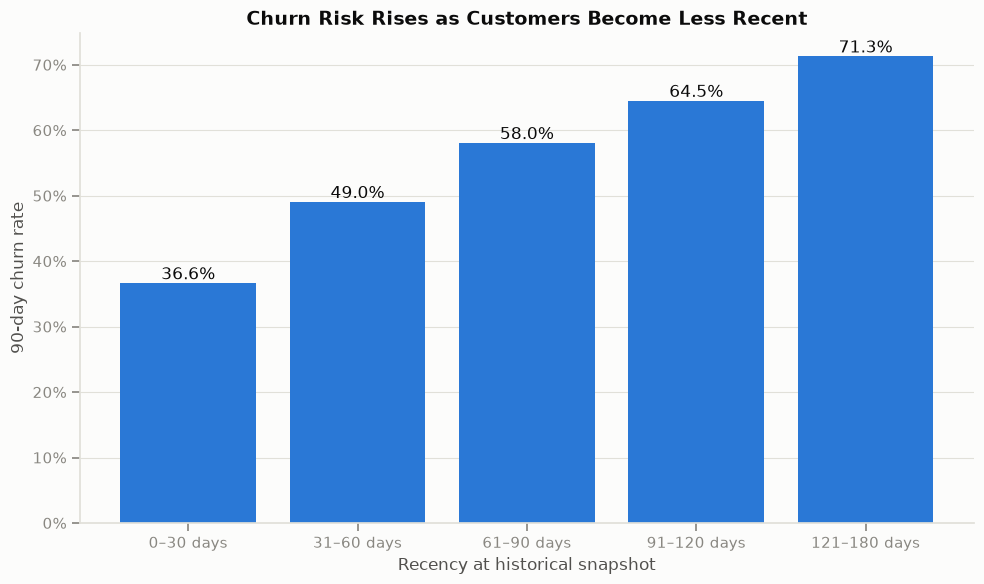

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    recency_prevalence["RecencyBand"].astype(str),
    recency_prevalence["ChurnRate"],
    color=BLUE,
)

for bar, rate in zip(
    bars,
    recency_prevalence["ChurnRate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom",
    )

ax.set_title(
    "Churn Risk Rises as Customers Become Less Recent",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Recency at historical snapshot")
ax.set_ylabel("90-day churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))

style_ax(ax)
plt.tight_layout()
plt.show()

Save the exploratory label table

In [42]:
SNAPSHOT_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "churn_label_sensitivity.csv"
)

SNAPSHOT_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

snapshot_labels.to_csv(
    SNAPSHOT_OUTPUT_PATH,
    index=False,
)

print(f"Saved: {SNAPSHOT_OUTPUT_PATH}")

Saved: c:\Users\ND\Desktop\Project No Surrender\data\processed\churn_label_sensitivity.csv


interpreting the results
We are comparing two separate pieces of evidence:
1. Interpurchase gaps
   Shows how long customers historically waited between completed purchases.
2. Historical snapshot prevalence
   Shows how many eligible customers would have been labelled churned if the rule had been applied on real historical dates.
A good horizon should:
- avoid labelling most normal customers too early;
- produce a manageable churn population;
- remain reasonably stable across snapshot dates;
- leave enough time for intervention;
- provide enough fully observed historical data for training.
The next decision is not automatically “choose the horizon with the lowest churn rate.” A longer horizon will always produce fewer churn labels because customers have more time to return.

- 60-day horizon  → earlier warning, more false alarms
- 90-day horizon  → balanced provisional choice
- 120-day horizon → more confidence, slower intervention
- 180-day horizon → strong inactivity evidence, often too late

# Observation-Window Sensitivity Analysis

The prediction horizon remains fixed at 90 days while the customer-history
window is compared across 90, 180 and 365 days.

This experiment changes only how much customer history is available before
each snapshot:

- 90-day history;
- 180-day history;
- 365-day history.

All alternatives use the same snapshot dates so differences are caused by the
observation window rather than seasonality or unequal data coverage.

The comparison examines:

- eligible customers;
- churn-label prevalence;
- one-purchase versus repeat-customer composition;
- Recency distribution;
- customer history available for feature engineering;
- stability across snapshot dates.

In [43]:
HISTORY_WINDOWS = [90, 180, 270, 360]
FIXED_CHURN_HORIZON = 90

MAX_HISTORY_WINDOW = max(HISTORY_WINDOWS)

# Every history window must use the same snapshots.
# The first snapshot must have a full 365 days of history.
common_first_snapshot = (
    dataset_start
    + pd.Timedelta(days=MAX_HISTORY_WINDOW)
)

# Every snapshot must have a complete 90-day future label window.
common_last_snapshot = (
    dataset_end
    - pd.Timedelta(days=FIXED_CHURN_HORIZON)
)

# Month-start snapshots only.
history_sensitivity_snapshots = pd.date_range(
    start=common_first_snapshot,
    end=common_last_snapshot,
    freq="MS",
)

print(f"Fixed churn horizon: {FIXED_CHURN_HORIZON} days")
print(f"History windows tested: {HISTORY_WINDOWS}")
print(
    "Common snapshot period:",
    history_sensitivity_snapshots.min().date(),
    "to",
    history_sensitivity_snapshots.max().date(),
)
print(
    "Common monthly snapshots:",
    len(history_sensitivity_snapshots),
)

Fixed churn horizon: 90 days
History windows tested: [90, 180, 270, 360]
Common snapshot period: 2010-12-01 to 2011-09-01
Common monthly snapshots: 10


In [44]:
history_sensitivity_frames = []

for history_days in HISTORY_WINDOWS:
    history_result = build_snapshot_labels(
        purchase_days=purchase_days,
        snapshot_dates=history_sensitivity_snapshots,
        horizons=[FIXED_CHURN_HORIZON],
        observation_days=history_days,
    )

    history_result["HistoryWindowDays"] = history_days

    history_sensitivity_frames.append(history_result)

history_sensitivity_df = pd.concat(
    history_sensitivity_frames,
    ignore_index=True,
)

print(
    "Sensitivity-analysis rows:",
    f"{len(history_sensitivity_df):,}",
)

display(history_sensitivity_df.head())

Sensitivity-analysis rows: 131,887


,Customer ID,HistoryPurchaseDays,HistoryInvoices,HistoryMonetary,FirstPurchaseInWindow,LastPurchaseBeforeSnapshot,SnapshotDate,ObservationStart,RecencyAtSnapshot,ObservedTenureInWindow,CustomerStageAtSnapshot,NextPurchaseDate,DaysToNextPurchase,HorizonDays,LabelEndDate,ReturnedWithinHorizon,Churn,HistoryWindowDays
0,12347,1,1,611.53,2010-10-31,2010-10-31,2010-12-01,2010-09-02,31,0,One purchase day,2010-12-07,6.0,90,2011-03-01,1,0,90
1,12348,1,1,221.16,2010-09-27,2010-09-27,2010-12-01,2010-09-02,65,0,One purchase day,2010-12-16,15.0,90,2011-03-01,1,0,90
2,12349,1,1,1152.62,2010-10-28,2010-10-28,2010-12-01,2010-09-02,34,0,One purchase day,2011-11-21,355.0,90,2011-03-01,0,1,90
3,12351,1,1,300.93,2010-11-29,2010-11-29,2010-12-01,2010-09-02,2,0,One purchase day,NaT,NaN,90,2011-03-01,0,1,90
4,12352,2,2,333.90,2010-11-12,2010-11-29,2010-12-01,2010-09-02,2,17,Repeat purchase days,2011-02-16,77.0,90,2011-03-01,1,0,90


In [45]:
assert history_sensitivity_df[
    "HistoryWindowDays"
].isin(HISTORY_WINDOWS).all()

assert (
    history_sensitivity_df["HorizonDays"]
    == FIXED_CHURN_HORIZON
).all()

assert history_sensitivity_df["Churn"].isin([0, 1]).all()

assert not history_sensitivity_df[
    [
        "Customer ID",
        "SnapshotDate",
        "HistoryWindowDays",
    ]
].duplicated().any()

assert (
    history_sensitivity_df["LastPurchaseBeforeSnapshot"]
    < history_sensitivity_df["SnapshotDate"]
).all()

assert (
    history_sensitivity_df["LabelEndDate"]
    <= dataset_end
).all()

assert (
    history_sensitivity_df["RecencyAtSnapshot"]
    <= history_sensitivity_df["HistoryWindowDays"]
).all()

assert (
    history_sensitivity_df["HistoryPurchaseDays"]
    >= 1
).all()

print("All observation-window sensitivity checks passed.")

All observation-window sensitivity checks passed.


In [46]:
for snapshot_date in history_sensitivity_snapshots:
    snapshot_population = history_sensitivity_df[
        history_sensitivity_df["SnapshotDate"] == snapshot_date
    ]

    customer_sets = {
        window: set(
            snapshot_population.loc[
                snapshot_population["HistoryWindowDays"] == window,
                "Customer ID",
            ]
        )
        for window in HISTORY_WINDOWS
    }

    for shorter, longer in zip(
        HISTORY_WINDOWS[:-1],
        HISTORY_WINDOWS[1:],
    ):
        assert customer_sets[shorter].issubset(
            customer_sets[longer]
        )

print("All longer windows contain their shorter-window populations.")

All longer windows contain their shorter-window populations.


In [47]:
history_by_snapshot = (
    history_sensitivity_df
    .groupby(
        ["HistoryWindowDays", "SnapshotDate"],
        as_index=False,
    )
    .agg(
        EligibleCustomers=("Customer ID", "nunique"),
        ChurnRate=("Churn", "mean"),
        MedianRecency=("RecencyAtSnapshot", "median"),
        MeanPurchaseDays=("HistoryPurchaseDays", "mean"),
        MeanInvoices=("HistoryInvoices", "mean"),
        MeanMonetary=("HistoryMonetary", "mean"),
    )
)

display(history_by_snapshot.head())

,HistoryWindowDays,SnapshotDate,EligibleCustomers,ChurnRate,MedianRecency,MeanPurchaseDays,MeanInvoices,MeanMonetary
0,90,2010-12-01,2856,0.578081,26.0,1.932073,2.191176,1001.580908
1,90,2011-01-01,2639,0.576355,41.0,2.000758,2.265252,1110.708064
2,90,2011-02-01,2176,0.529412,55.0,1.963695,2.203125,1096.766007
3,90,2011-03-01,1679,0.432996,33.0,1.834425,2.002978,1048.915080
4,90,2011-04-01,1771,0.418408,29.0,1.745906,1.851496,829.982530


In [48]:
overall_history_summary = (
    history_sensitivity_df
    .groupby("HistoryWindowDays", as_index=False)
    .agg(
        CustomerSnapshots=("Customer ID", "size"),
        UniqueCustomers=("Customer ID", "nunique"),
        ChurnRate=("Churn", "mean"),
        MedianRecency=("RecencyAtSnapshot", "median"),
        MedianPurchaseDays=("HistoryPurchaseDays", "median"),
        MedianInvoices=("HistoryInvoices", "median"),
        MedianMonetary=("HistoryMonetary", "median"),
        OnePurchaseShare=(
            "CustomerStageAtSnapshot",
            lambda s: (s == "One purchase day").mean(),
        ),
    )
)

average_population = (
    history_by_snapshot
    .groupby("HistoryWindowDays", as_index=False)
    .agg(
        AverageEligibleCustomers=(
            "EligibleCustomers",
            "mean",
        ),
        MinimumEligibleCustomers=(
            "EligibleCustomers",
            "min",
        ),
        MaximumEligibleCustomers=(
            "EligibleCustomers",
            "max",
        ),
        ChurnRateStd=(
            "ChurnRate",
            "std",
        ),
    )
)

overall_history_summary = overall_history_summary.merge(
    average_population,
    on="HistoryWindowDays",
    how="left",
    validate="one_to_one",
)

display(
    overall_history_summary.style.format({
        "CustomerSnapshots": "{:,}",
        "UniqueCustomers": "{:,}",
        "ChurnRate": "{:.1%}",
        "MedianRecency": "{:.0f}",
        "MedianPurchaseDays": "{:.1f}",
        "MedianInvoices": "{:.1f}",
        "MedianMonetary": "£{:,.0f}",
        "OnePurchaseShare": "{:.1%}",
        "AverageEligibleCustomers": "{:,.0f}",
        "MinimumEligibleCustomers": "{:,}",
        "MaximumEligibleCustomers": "{:,}",
        "ChurnRateStd": "{:.3f}",
    })
)

,HistoryWindowDays,CustomerSnapshots,UniqueCustomers,ChurnRate,MedianRecency,MedianPurchaseDays,MedianInvoices,MedianMonetary,OnePurchaseShare,AverageEligibleCustomers,MinimumEligibleCustomers,MaximumEligibleCustomers,ChurnRateStd
0,90,"20,862","4,309",45.8%,34,1.0,1.0,£427,61.2%,"2,086","1,679","2,856",0.087
1,180,"30,749","4,657",53.9%,57,2.0,2.0,£531,48.3%,"3,075","2,654","3,453",0.078
2,270,"37,704","4,970",59.1%,78,2.0,2.0,£610,41.2%,"3,770","3,252","3,921",0.066
3,360,"42,572","5,190",61.6%,94,2.0,2.0,£661,37.3%,"4,257","4,191","4,300",0.050


| Column | Meaning |
|---|---|
| `CustomerSnapshots` | Total modelling rows |
| `UniqueCustomers` | Distinct customers appearing in the experiment |
| `ChurnRate` | Percentage with no purchase in the following 90 days |
| `MedianRecency` | Typical inactivity at prediction time |
| `MedianPurchaseDays` | Typical number of purchase days available as history |
| `MedianInvoices` | Typical number of historical invoices |
| `MedianMonetary` | Typical historical customer value |
| `OnePurchaseShare` | Share with only one purchase day in the window |
| `AverageEligibleCustomers` | Typical number scored per month |
| `ChurnRateStd` | How much the churn rate changes across snapshots |

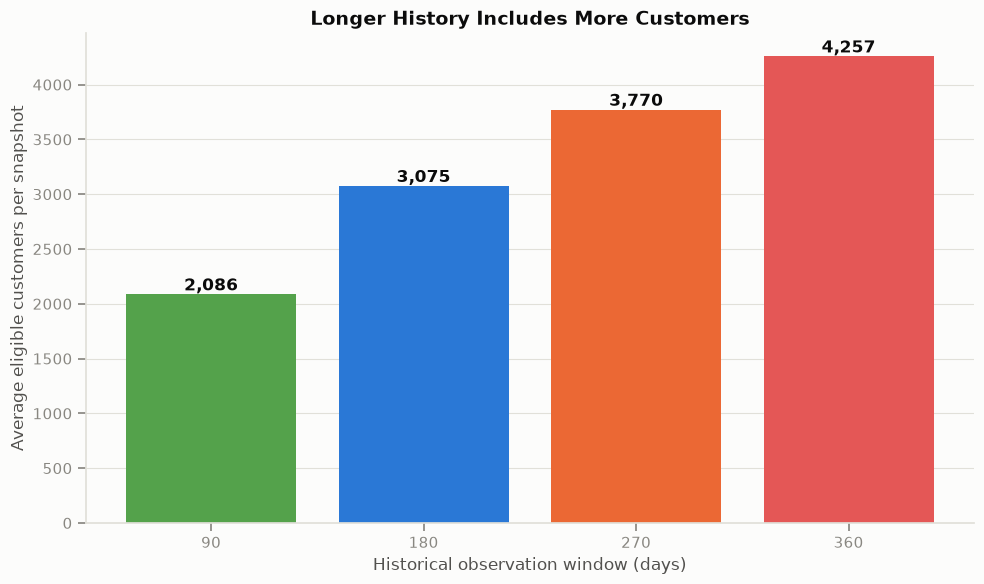

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    overall_history_summary[
        "HistoryWindowDays"
    ].astype(str),
    overall_history_summary[
        "AverageEligibleCustomers"
    ],
    color=[GREEN, BLUE, ORANGE, RED],
)

for bar, value in zip(
    bars,
    overall_history_summary[
        "AverageEligibleCustomers"
    ],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        weight="bold",
    )

ax.set_title(
    "Longer History Includes More Customers",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Historical observation window (days)")
ax.set_ylabel("Average eligible customers per snapshot")

style_ax(ax)
plt.tight_layout()
plt.show()

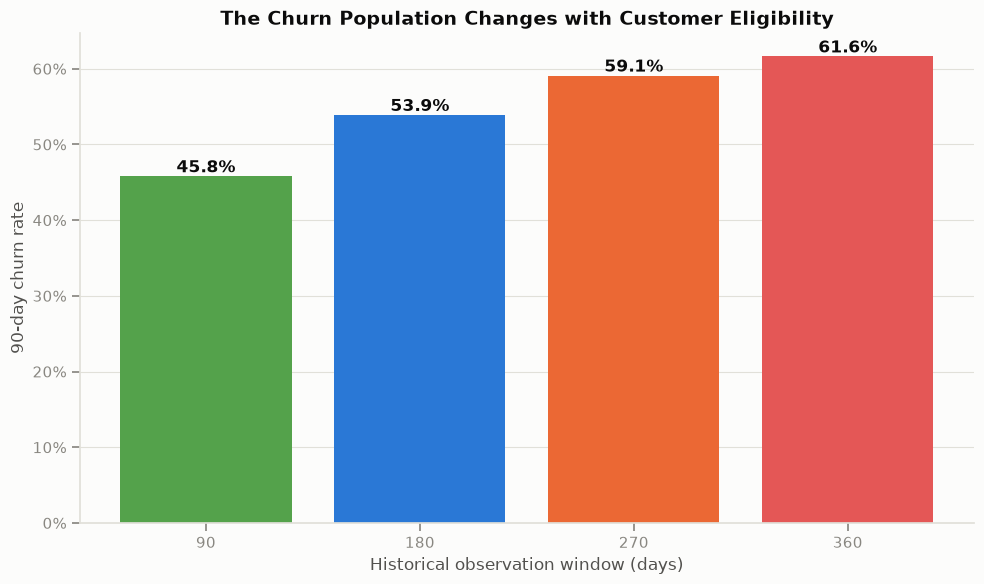

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    overall_history_summary[
        "HistoryWindowDays"
    ].astype(str),
    overall_history_summary["ChurnRate"],
    color=[GREEN, BLUE, ORANGE, RED],
)

for bar, rate in zip(
    bars,
    overall_history_summary["ChurnRate"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1%}",
        ha="center",
        va="bottom",
        weight="bold",
    )

ax.set_title(
    "The Churn Population Changes with Customer Eligibility",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Historical observation window (days)")
ax.set_ylabel("90-day churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))

style_ax(ax)
plt.tight_layout()
plt.show()

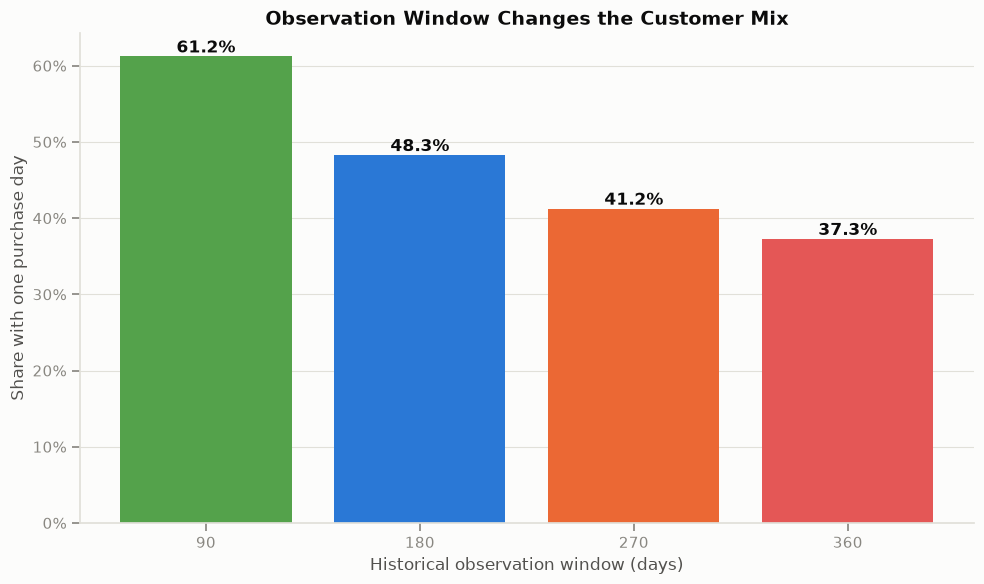

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    overall_history_summary[
        "HistoryWindowDays"
    ].astype(str),
    overall_history_summary[
        "OnePurchaseShare"
    ],
    color=[GREEN, BLUE, ORANGE, RED],
)

for bar, share in zip(
    bars,
    overall_history_summary[
        "OnePurchaseShare"
    ],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{share:.1%}",
        ha="center",
        va="bottom",
        weight="bold",
    )

ax.set_title(
    "Observation Window Changes the Customer Mix",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Historical observation window (days)")
ax.set_ylabel("Share with one purchase day")
ax.yaxis.set_major_formatter(PercentFormatter(1))

style_ax(ax)
plt.tight_layout()
plt.show()

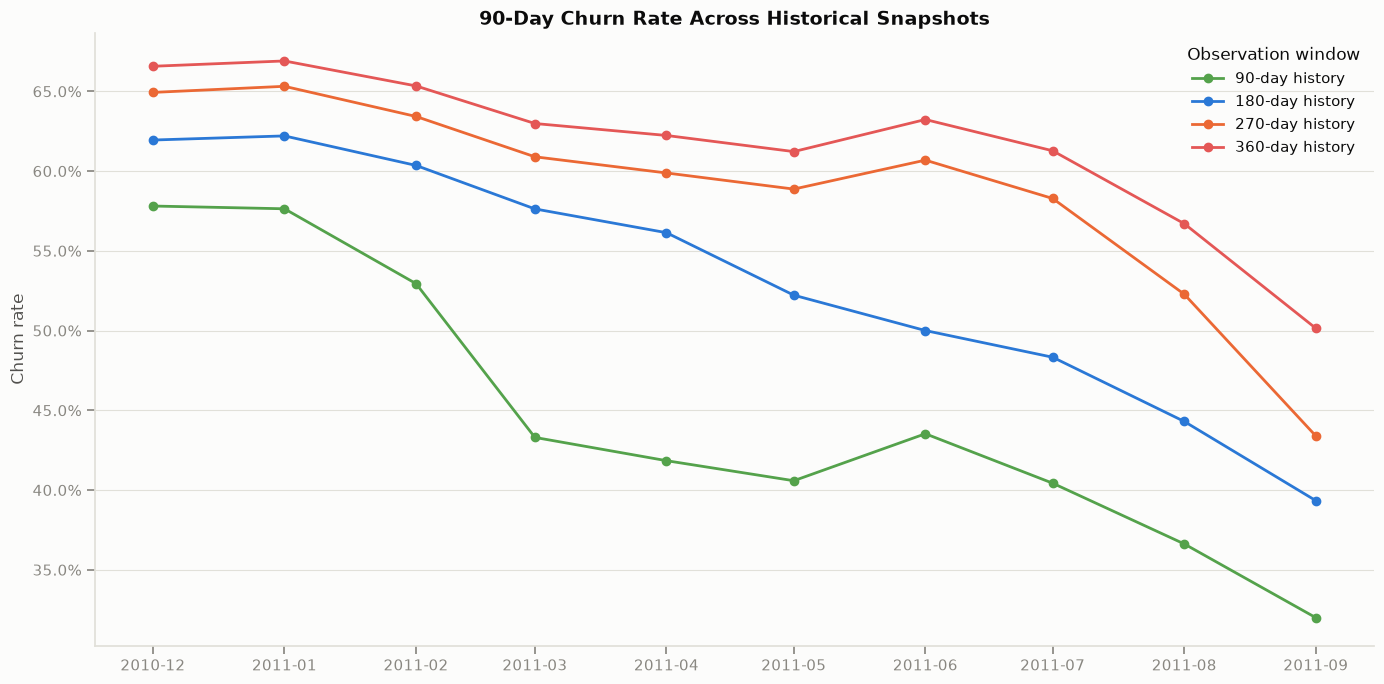

In [52]:
fig, ax = plt.subplots(figsize=(14, 7))

history_colors = {
    90: GREEN,
    180: BLUE,
    270: ORANGE,
    360: RED,
}

for history_days in HISTORY_WINDOWS:
    plot_data = history_by_snapshot[
        history_by_snapshot["HistoryWindowDays"]
        == history_days
    ]

    ax.plot(
        plot_data["SnapshotDate"],
        plot_data["ChurnRate"],
        marker="o",
        linewidth=2,
        color=history_colors[history_days],
        label=f"{history_days}-day history",
    )

ax.set_title(
    "90-Day Churn Rate Across Historical Snapshots",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(
    title="Observation window",
    frameon=False,
)

style_ax(ax)
plt.tight_layout()
plt.show()

In [53]:
incremental_rows = []

window_pairs = list(
    zip(
        HISTORY_WINDOWS[:-1],
        HISTORY_WINDOWS[1:],
    )
)

for snapshot_date in history_sensitivity_snapshots:
    snapshot_data = history_sensitivity_df[
        history_sensitivity_df["SnapshotDate"]
        == snapshot_date
    ]

    for shorter_window, longer_window in window_pairs:
        shorter_customers = set(
            snapshot_data.loc[
                snapshot_data["HistoryWindowDays"]
                == shorter_window,
                "Customer ID",
            ]
        )

        longer_data = snapshot_data[
            snapshot_data["HistoryWindowDays"]
            == longer_window
        ].copy()

        added_data = longer_data[
            ~longer_data["Customer ID"].isin(
                shorter_customers
            )
        ]

        incremental_rows.append({
            "SnapshotDate": snapshot_date,
            "Comparison": (
                f"Added by {longer_window} vs "
                f"{shorter_window} days"
            ),
            "AddedCustomers": len(added_data),
            "AddedCustomerChurnRate": (
                added_data["Churn"].mean()
                if len(added_data) > 0
                else np.nan
            ),
            "AddedCustomerMedianRecency": (
                added_data["RecencyAtSnapshot"].median()
                if len(added_data) > 0
                else np.nan
            ),
            "AddedCustomerOnePurchaseShare": (
                (
                    added_data["CustomerStageAtSnapshot"]
                    == "One purchase day"
                ).mean()
                if len(added_data) > 0
                else np.nan
            ),
        })

incremental_population = pd.DataFrame(
    incremental_rows
)

incremental_summary = (
    incremental_population
    .groupby("Comparison", as_index=False)
    .agg(
        AverageAddedCustomers=(
            "AddedCustomers",
            "mean",
        ),
        AddedCustomerChurnRate=(
            "AddedCustomerChurnRate",
            "mean",
        ),
        AddedCustomerMedianRecency=(
            "AddedCustomerMedianRecency",
            "median",
        ),
        AddedCustomerOnePurchaseShare=(
            "AddedCustomerOnePurchaseShare",
            "mean",
        ),
    )
)

display(
    incremental_summary.style.format({
        "AverageAddedCustomers": "{:,.0f}",
        "AddedCustomerChurnRate": "{:.1%}",
        "AddedCustomerMedianRecency": "{:.0f} days",
        "AddedCustomerOnePurchaseShare": "{:.1%}",
    })
)

,Comparison,AverageAddedCustomers,AddedCustomerChurnRate,AddedCustomerMedianRecency,AddedCustomerOnePurchaseShare
0,Added by 180 vs 90 days,989,70.8%,129 days,79.3%
1,Added by 270 vs 180 days,696,81.9%,222 days,81.6%
2,Added by 360 vs 270 days,487,83.2%,308 days,84.6%


That means most of the additional customers in 270 days:
- purchased only once;
- have already been absent for over seven months;
- are very unlikely to return within the next 90 days.
In simple terms:
The extra customers captured by 270 days are mostly already deeply inactive. We are discovering churn late rather than predicting it early.

In [54]:
window_decision = overall_history_summary[
    [
        "HistoryWindowDays",
        "AverageEligibleCustomers",
        "ChurnRate",
        "OnePurchaseShare",
        "MedianRecency",
        "MedianPurchaseDays",
        "ChurnRateStd",
    ]
].copy()

window_decision["BusinessInterpretation"] = (
    window_decision["HistoryWindowDays"].map({
        90: (
            "Recent population, but too little history and "
            "excludes many occasional customers."
        ),
        180: (
            "Best balance of customer coverage, behavioural "
            "history and timely intervention."
        ),
        270: (
            "Includes more customers, but many added customers "
            "are already deeply inactive."
        ),
        360: (
            "Captures older relationships that are likely "
            "already lost and harder to reactivate."
        ),
    })
)

display(
    window_decision.style.format({
        "AverageEligibleCustomers": "{:,.0f}",
        "ChurnRate": "{:.1%}",
        "OnePurchaseShare": "{:.1%}",
        "MedianRecency": "{:.0f} days",
        "MedianPurchaseDays": "{:.1f}",
        "ChurnRateStd": "{:.3f}",
    })
)

,HistoryWindowDays,AverageEligibleCustomers,ChurnRate,OnePurchaseShare,MedianRecency,MedianPurchaseDays,ChurnRateStd,BusinessInterpretation
0,90,"2,086",45.8%,61.2%,34 days,1.0,0.087,"Recent population, but too little history and excludes many occasional customers."
1,180,"3,075",53.9%,48.3%,57 days,2.0,0.078,"Best balance of customer coverage, behavioural history and timely intervention."
2,270,"3,770",59.1%,41.2%,78 days,2.0,0.066,"Includes more customers, but many added customers are already deeply inactive."
3,360,"4,257",61.6%,37.3%,94 days,2.0,0.050,Captures older relationships that are likely already lost and harder to reactivate.


90 days:
- Too little history and too few customers. Ninety days tells us a lot about very recent customers, but not enough about how their behaviour is changing.

180 days:
- Enough history, good customer coverage and still actionable. Six months gives us enough history to understand a customer, while they are still recent enough for the business to act. 180 days is long enough to understand the customer, but short enough to act before the customer is probably gone.

That lets the model measure whether:
- orders are decreasing;
- spending is declining;
- purchase gaps are increasing;
- the customer is becoming less active.
Its 53.9% churn rate is also well balanced for modelling.

270 days:
- Adds mostly customers already inactive for a long time. The extra customers captured by 270 days are mostly already deeply inactive. We are discovering churn late rather than predicting it early.

360 days:
- Adds even older and more obvious churn cases. A one-year window catches more customers, but many are old relationships that are probably already lost.

#### Final recommendation
Use:

- 180-day observation window
- 90-day prediction horizon
- Monthly historical snapshots.. 

- Meaning: Look back 180 days → make prediction → observe the next 90 days. Then move the snapshot forward by one month and repeat.
- Historical observation             Snapshot       Prediction horizon
3 Dec 2009 ─────── 31 May 2010     1 Jun 2010     1 Jun ───── 30 Aug 2010
        Previous 180 days                              Following 90 days


        We look back 180 days from each monthly snapshot, use that history to predict whether the customer will purchase during the next 90 days, move forward one month, and repeat.

### The full sequence - rolling historical snapshot design

Snapshot 1:
Past 180 days → 1 June → following 90 days

Snapshot 2:
Past 180 days → 1 July → following 90 days

Snapshot 3:
Past 180 days → 1 August → following 90 days

Snapshot 4:
Past 180 days → 1 September → following 90 days

This means:
At each monthly snapshot, examine the customer’s previous six months of behaviour and predict whether they will make a purchase during the following three months.

Older information can still be used for special features such as:
- total customer tenure;
- lifetime spending;
- annual or holiday purchasing;
- previous-year activity.
But customers should qualify for churn scoring only if they purchased during the previous 180 days.

I selected 180 days because 90 days excluded too many legitimate slower customers and provided too little history, while customers added by 270 and 360 days had already been inactive for roughly seven to ten months and were mostly obvious, late-stage churn cases.

That is why 180 days is the most appropriate compromise for this project.

### Why move monthly?
In production, the company might refresh churn scores monthly.
Historical monthly snapshots simulate that process:

Start of every month:
1. Refresh customer history.
2. Recalculate features.
3. Produce churn probabilities.
4. Select customers for intervention.

### What the previous 180 days do
They provide the information known when the prediction is made:
- days since last purchase;
- orders in the last 30, 60, 90 and 180 days;
- spending in those periods;
- one-time or repeat-customer status;
- changes in orders and spending;
- purchasing cadence;
- cancellation behaviour.
They also determine eligibility:
At least one retained purchase in previous 180 days
→ customer is eligible for scoring

No retained purchase in previous 180 days
→ customer is outside the current churn-scoring population

### What the following 90 days do
They create the historical outcome:
- Future purchase exists → customer returned → Churn = 0
- No future purchase     → customer inactive → Churn = 1

The model does not get access to this future information. It is used only as the answer the model must learn to predict.

# Final Churn Policy

The project will use:

- **Observation window:** previous 180 days
- **Prediction horizon:** following 90 days
- **Snapshot frequency:** monthly
- **Eligibility:** at least one retained purchase in the previous 180 days
- **Churn = 1:** no retained purchase during the following 90 days
- **Churn = 0:** at least one retained purchase during the following 90 days

The 180-day history provides enough activity to measure customer behaviour
while keeping the population recent enough for intervention. The 90-day
outcome creates a reasonably balanced target and leaves sufficient time for
retention activity.

One-purchase and repeat customers will remain in the same initial modelling
population, but model performance and recommended actions will be evaluated
separately for both groups.